## PROJET STOCK MARKET - PREDICTION DE EARNINGS Partie 1


Dans ce projet, l'objectif est de prédire la variable "earnings" du mois suivant à partir de plusieurs variables financières issues de la table standardandpoor.

In [678]:
#imports
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mysql.connector
import tensorflow as tf

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from data_windowing import WindowGenerator
print(WindowGenerator)

<class 'data_windowing.WindowGenerator'>


# Parametres

In [ ]:

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

INPUT_WIDTH = 5
LABEL_WIDTH = 1
SHIFT = 1

P_VAL = 0.1
P_TEST = 0.1

EPOCHS = 30
BATCH_SIZE = 32

FIGSIZE = (12, 6)

print("Paramètres chargés.")
print("Seed utilisée :", SEED)

Paramètres chargés.
Seed utilisée : 42


Cette partie du code permet de définir les paramètres généraux utilisés dans le projet. On fixe notamment une graine aléatoire (« seed »), ce qui permet de rendre les résultats reproductibles : si l’on exécute le programme plusieurs fois, on obtient les mêmes résultats. Le code définit également plusieurs hyperparamètres. Un hyperparamètre est un paramètre choisi par le programmeur avant l’entraînement du modèle, qui sert à contrôler le fonctionnement de l’algorithme. Par exemple, on définit ici la taille des fenêtres temporelles utilisées comme entrée du modèle, la proportion des données utilisées pour la validation et le test, le nombre d’époques (c’est-à-dire le nombre de fois que le modèle parcourt l’ensemble des données d’entraînement) ainsi que la taille des lots de données utilisés pendant l’apprentissage. Cette étape est importante car elle organise le cadre de l’expérience et garantit que les modèles seront entraînés de manière cohérente et comparable.


# Connexion a la base de donnees

In [680]:
config = {
    "user": "root",
    "password": "root",
    "host": "localhost",
    "database": "sdd4",
    "raise_on_warnings": True
}

bdd = mysql.connector.connect(**config)
print("Connexion à MySQL réussie.")

Connexion à MySQL réussie.


# Importation des donnees 

In [681]:

sp = pd.read_sql("""
SELECT observation_date,
       sp500,
       dividend,
       earnings,
       longInterestRate,
       realPrice,
       realDividend,
       realEarnings
FROM standardandpoor
""", bdd)

bdd.close()

print("Dimensions du dataset brut :", sp.shape)
display(sp.head())

Dimensions du dataset brut : (1833, 8)


,observation_date,sp500,dividend,earnings,longInterestRate,realPrice,realDividend,realEarnings
0,1871-01-01,4.515,0.26,0.4,5.335,111.325,6.41,9.86
1,1871-02-01,4.500,0.26,0.4,5.320,107.250,6.20,9.53
2,1871-03-01,4.610,0.26,0.4,5.330,108.270,6.11,9.39
3,1871-04-01,4.740,0.26,0.4,5.330,115.540,6.34,9.75
4,1871-05-01,4.860,0.26,0.4,5.330,121.220,6.48,9.98


# Preparation des donnes 

In [682]:

sp = sp.rename(columns={"observation_date": "date"})

sp["date"] = pd.to_datetime(sp["date"], errors="coerce")
sp.dropna(subset=["date"], inplace=True)
sp["date"] = sp["date"].dt.normalize()
sp.sort_values("date", inplace=True)

data = sp.copy()
data = data.sort_values("date").reset_index(drop=True)

# Variable cible = earnings du mois suivant
data["target_earnings_next"] = data["earnings"].shift(-1)

# Suppression des valeurs manquantes
data = data.dropna().reset_index(drop=True)

print("Shape du dataset final :", data.shape)
display(data.head())

Shape du dataset final : (1832, 9)


,date,sp500,dividend,earnings,longInterestRate,realPrice,realDividend,realEarnings,target_earnings_next
0,1871-01-01,4.515,0.26,0.4,5.335,111.325,6.41,9.86,0.4
1,1871-02-01,4.500,0.26,0.4,5.320,107.250,6.20,9.53,0.4
2,1871-03-01,4.610,0.26,0.4,5.330,108.270,6.11,9.39,0.4
3,1871-04-01,4.740,0.26,0.4,5.330,115.540,6.34,9.75,0.4
4,1871-05-01,4.860,0.26,0.4,5.330,121.220,6.48,9.98,0.4


Cette partie du code orrespond a la preparation et au nettoyage des donnes. La colonne observation_date est convertie au au format de date avec pd.to_datetime,ce qui permet de manipuler correctement les données temporelles.

Les lignes contenant des dates invalides ou manquantes sont supprimées afin d’éviter des erreurs dans l’analyse. La fonction normalize() est utilisée pour conserver uniquement la date sans l’heure. Ce qui permet d’avoir une représentation uniforme des observations. Les données sont ensuite triées par ordre chronologique afin de respecter la logique temporelle de la série économique.

On a cree une copie du dataset afin de travailler sur une version organisée des données. Ensuite, on construit la variable cible du modèle en créant une nouvelle colonne appelée target_earnings_next. Cette colonne correspond à la valeur de earnings à la période suivante. Pour faire cela, on utilise la fonction shift(-1), qui décale la variable d’une ligne vers le haut. L’idée est de transformer le problème en un problème de prédiction : le modèle devra utiliser les informations disponibles à un moment donné pour essayer de prédire les earnings du mois suivant. Enfin, les lignes contenant des valeurs manquantes sont supprimées afin de garder un dataset propre et utilisable pour l’entraînement des modèles.



# Analyse exploratoire minimale 

In [683]:


print("Informations générales :")
display(data.info())

print("\nValeurs manquantes :")
display(data.isna().sum())

print("\nStatistiques descriptives :")
display(data.describe())

Informations générales :
<class 'pandas.DataFrame'>
RangeIndex: 1832 entries, 0 to 1831
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype        
---  ------                --------------  -----        
 0   date                  1832 non-null   datetime64[s]
 1   sp500                 1832 non-null   float64      
 2   dividend              1832 non-null   float64      
 3   earnings              1832 non-null   float64      
 4   longInterestRate      1832 non-null   float64      
 5   realPrice             1832 non-null   float64      
 6   realDividend          1832 non-null   float64      
 7   realEarnings          1832 non-null   float64      
 8   target_earnings_next  1832 non-null   float64      
dtypes: datetime64[s](1), float64(8)
memory usage: 128.9 KB


None


Valeurs manquantes :


date                    0
sp500                   0
dividend                0
earnings                0
longInterestRate        0
realPrice               0
realDividend            0
realEarnings            0
target_earnings_next    0
dtype: int64


Statistiques descriptives :


,date,sp500,dividend,earnings,longInterestRate,realPrice,realDividend,realEarnings,target_earnings_next
count,1832,1832.000000,1832.000000,1832.000000,1832.000000,1832.000000,1832.00000,1832.000000,1832.000000
mean,1947-04-17 03:32:14,375.265800,7.559061,17.790614,4.489443,742.153496,20.30527,41.348747,17.889288
min,1871-01-01 00:00:00,2.730000,0.180000,0.160000,0.620000,82.870000,6.11000,5.130000,0.160000
25%,1909-02-22 00:00:00,8.007500,0.420000,0.574375,3.150000,210.535000,10.58000,15.902500,0.575600
50%,1947-04-16 00:00:00,18.180000,0.930000,1.541500,3.800000,324.710000,16.22500,26.945000,1.550000
75%,1985-06-08 12:00:00,184.300000,7.747500,14.997475,5.100000,812.450000,25.77000,50.022500,15.012500
max,2023-08-01 00:00:00,4674.770000,68.710000,197.910000,15.320000,5140.590000,71.22000,217.260000,197.910000
std,NaN,803.453316,13.806601,35.019981,2.301481,911.488414,13.60716,37.918438,35.225026


On réalise une analyse exploratoire simple du dataset afin de mieux comprendre les données avant de construire les modèles. La fonction data.info() permet d’afficher des informations générales sur le dataset, comme le nombre de lignes, les types de variables et la présence éventuelle de valeurs manquantes. Ensuite, data.isna().sum() est utilisé pour vérifier s’il existe des valeurs manquantes dans chaque colonne. Cette étape est importante car les valeurs manquantes peuvent poser problème lors de l’entraînement des modèles. Enfin, la fonction data.describe() permet d’obtenir des statistiques descriptives sur les variables numériques, comme la moyenne, l’écart-type, les valeurs minimales et maximales ou encore les quartiles. Cela permet d’avoir une première idée de la distribution des données et de détecter d’éventuelles valeurs atypiques.

# Visualisation HISTORIQUE EARNINGS

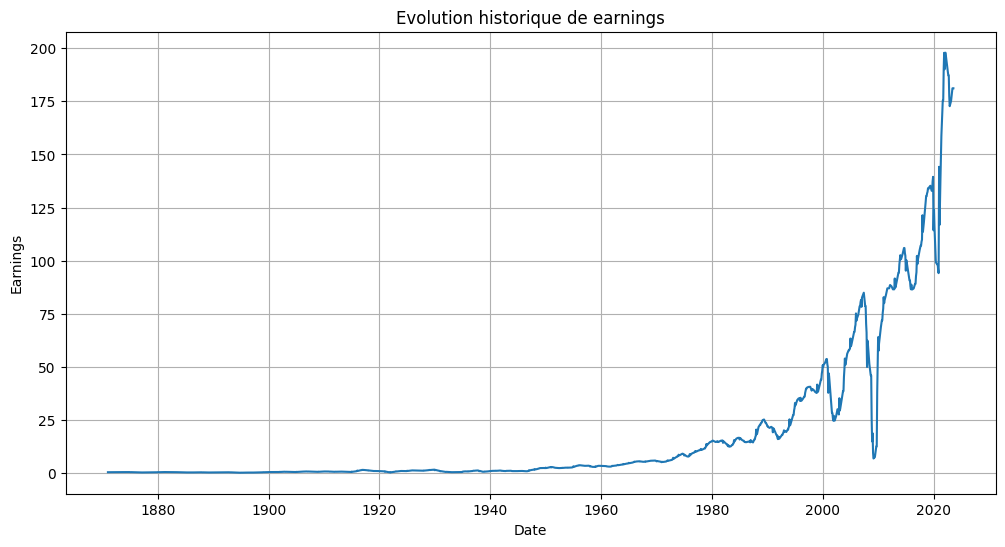

In [684]:
plt.figure(figsize=FIGSIZE)
plt.plot(data["date"], data["earnings"])
plt.title("Evolution historique de earnings")
plt.xlabel("Date")
plt.ylabel("Earnings")
plt.grid(True)
plt.show()

Dans cette partie, on réalise une visualisation de l’évolution historique de la variable earnings. Le graphique est construit avec la bibliothèque matplotlib et permet de représenter les valeurs de earnings au cours du temps en utilisant la colonne date sur l’axe horizontal et les valeurs d’earnings sur l’axe vertical. L’objectif de cette visualisation est d’observer la tendance générale de la série temporelle et de mieux comprendre comment cette variable évolue au fil des années. Ce type de graphique est utile dans l’analyse exploratoire car il permet de détecter des tendances, des périodes de forte croissance ou d’éventuelles variations importantes dans les données. Cela aide aussi à vérifier que les données sont cohérentes avant de les utiliser pour entraîner les modèles de prédiction.


# Variable a predire 

In [685]:


target_col = "target_earnings_next"

features = [
    "sp500",
    "dividend",
    "earnings",
    "longInterestRate",
    "realPrice",
    "realDividend",
    "realEarnings"
]

df_model = data[features + [target_col]].copy()
df_model = df_model.dropna().reset_index(drop=True)

print("Colonnes utilisées :")
print(df_model.columns.tolist())
print("Nombre de lignes :", len(df_model))
display(df_model.head())

Colonnes utilisées :
['sp500', 'dividend', 'earnings', 'longInterestRate', 'realPrice', 'realDividend', 'realEarnings', 'target_earnings_next']
Nombre de lignes : 1832


,sp500,dividend,earnings,longInterestRate,realPrice,realDividend,realEarnings,target_earnings_next
0,4.515,0.26,0.4,5.335,111.325,6.41,9.86,0.4
1,4.500,0.26,0.4,5.320,107.250,6.20,9.53,0.4
2,4.610,0.26,0.4,5.330,108.270,6.11,9.39,0.4
3,4.740,0.26,0.4,5.330,115.540,6.34,9.75,0.4
4,4.860,0.26,0.4,5.330,121.220,6.48,9.98,0.4


Dans cette partie du code, on sélectionne les variables qui seront utilisées pour construire le modèle de prédiction. Tout d’abord, on définit la variable cible appelée target_earnings_next. Cette variable correspond à la valeur que le modèle devra prédire, c’est-à-dire les earnings de la période suivante. Ensuite, on définit une liste appelée features, qui contient les variables explicatives du modèle, comme sp500, dividend, earnings, longInterestRate, realPrice, realDividend et realEarnings. Ces variables représentent différentes informations économiques qui peuvent aider à expliquer l’évolution des earnings.

À partir de ces variables, on crée un nouveau dataset appelé df_model, qui contient uniquement les variables explicatives et la variable cible. Cela permet de travailler sur un dataset plus simple et directement adapté au modèle. Les lignes contenant des valeurs manquantes sont ensuite supprimées afin d’éviter des problèmes lors de l’entraînement. Enfin, le code affiche les colonnes utilisées ainsi que le nombre total de lignes, ce qui permet de vérifier que les données ont été correctement préparées avant de continuer les étapes suivantes du projet.


# MATRICE DE CORRELATION

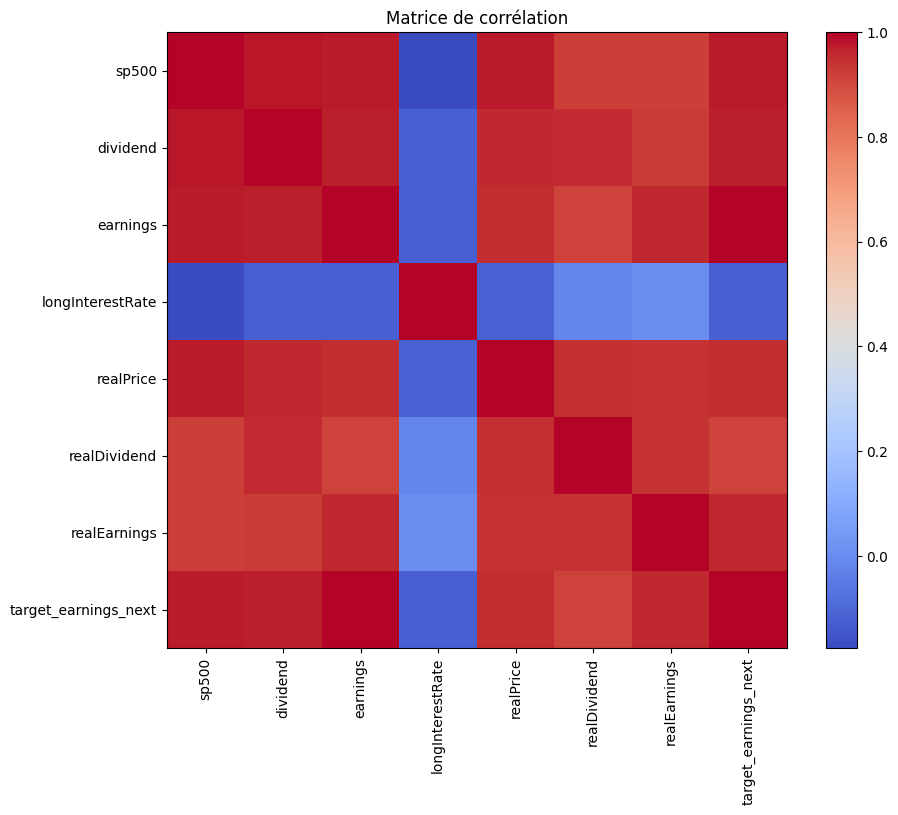

,sp500,dividend,earnings,longInterestRate,realPrice,realDividend,realEarnings,target_earnings_next
sp500,1.000000,0.979141,0.974785,-0.175923,0.976388,0.919708,0.919835,0.975198
dividend,0.979141,1.000000,0.971329,-0.117346,0.958761,0.955773,0.927624,0.970604
earnings,0.974785,0.971329,1.000000,-0.122942,0.950448,0.916917,0.961970,0.998036
longInterestRate,-0.175923,-0.117346,-0.122942,1.000000,-0.114560,-0.016527,0.006143,-0.123807
realPrice,0.976388,0.958761,0.950448,-0.114560,1.000000,0.946717,0.941572,0.950902
realDividend,0.919708,0.955773,0.916917,-0.016527,0.946717,1.000000,0.943417,0.916093
realEarnings,0.919835,0.927624,0.961970,0.006143,0.941572,0.943417,1.000000,0.959851
target_earnings_next,0.975198,0.970604,0.998036,-0.123807,0.950902,0.916093,0.959851,1.000000


In [686]:
corr = df_model.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matrice de corrélation")
plt.show()

display(corr)

Dans cette partie, on calcule et on visualise la matrice de corrélation entre les différentes variables du dataset. La corrélation permet de mesurer le lien entre deux variables : une valeur proche de 1 signifie que les variables évoluent de manière similaire, tandis qu’une valeur proche de 0 indique qu’il n’y a pas de relation forte entre elles. Le code utilise la fonction df_model.corr() pour calculer ces relations entre toutes les variables sélectionnées. Ensuite, une représentation graphique est réalisée avec matplotlib afin de visualiser plus facilement ces corrélations sous forme de carte de couleurs. Cette visualisation permet d’identifier quelles variables sont fortement liées entre elles et lesquelles peuvent être les plus utiles pour expliquer ou prédire l’évolution des earnings. Cela aide à mieux comprendre la structure des données avant de construire les modèles de prédiction.

On remarque d’abord que plusieurs variables financières sont fortement corrélées entre elles, notamment sp500, dividend, earnings, realPrice, realDividend et realEarnings. Ces corrélations élevées sont logiques car ces variables décrivent toutes l’évolution générale du marché financier et suivent souvent des tendances similaires dans le temps.

On observe également que la variable cible target_earnings_next est fortement corrélée avec certaines variables comme earnings, sp500 et realEarnings. Cela est cohérent puisque les earnings futurs sont souvent liés à leur valeur actuelle ainsi qu’à la dynamique globale du marché.


# FONCTIONS 

In [687]:


def split_indices(n, p_val=0.1, p_test=0.1):
    train_end = int(n * (1 - p_val - p_test))
    val_end = int(n * (1 - p_test))
    return train_end, val_end


def standardize_with_train_stats(df):
    """
    Standardisation avec la moyenne et l'écart-type du train seulement.
    """
    train_end, _ = split_indices(len(df), P_VAL, P_TEST)

    train_df = df.iloc[:train_end].copy()

    mean = train_df.mean()
    std = train_df.std()
    std = std.replace(0, 1)

    df_scaled = (df - mean) / std

    return df_scaled, mean, std


def extract_target_from_labels(label_array, target_index):
    """
    Les labels de WindowGenerator contiennent toutes les colonnes.
    On extrait uniquement la colonne cible.
    """
    label_array = np.array(label_array)

    if label_array.ndim == 3:
        y = label_array[:, :, target_index]
    elif label_array.ndim == 2:
        y = label_array[:, target_index]
    else:
        raise ValueError(f"Shape inattendue pour les labels : {label_array.shape}")

    return y.astype(np.float32).reshape(-1, 1)


def inverse_transform_target(y_scaled, mean, std, target_col):
    return y_scaled * std[target_col] + mean[target_col]


def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


df_scaled, mean, std = standardize_with_train_stats(df_model)
print("Shape de df_scaled :", df_scaled.shape)
display(df_scaled.head())

Shape de df_scaled : (1832, 8)


,sp500,dividend,earnings,longInterestRate,realPrice,realDividend,realEarnings,target_earnings_next
0,-0.553415,-0.597148,-0.592173,0.289475,-1.105990,-1.445225,-1.138339,-0.5929
1,-0.553602,-0.597148,-0.592173,0.283229,-1.124542,-1.480458,-1.161246,-0.5929
2,-0.552231,-0.597148,-0.592173,0.287393,-1.119898,-1.495557,-1.170964,-0.5929
3,-0.550612,-0.597148,-0.592173,0.287393,-1.086800,-1.456969,-1.145975,-0.5929
4,-0.549117,-0.597148,-0.592173,0.287393,-1.060941,-1.433481,-1.130010,-0.5929


On définit plusieurs fonctions qui servent à préparer les données avant l’entraînement des modèles. La fonction split_indices permet de calculer les indices qui séparent les données en trois parties : le jeu d’entraînement, le jeu de validation et le jeu de test. Cette séparation est importante pour pouvoir entraîner le modèle sur une partie des données et évaluer ses performances sur des données qu’il n’a jamais vues.

Ensuite, la fonction standardize_with_train_stats permet de standardiser les variables numériques. La standardisation consiste à transformer les données en utilisant la moyenne et l’écart-type calculés uniquement sur le jeu d’entraînement. Cela permet d’éviter les biais et de garantir que les informations du jeu de test ne soient pas utilisées pendant l’entraînement du modèle.

La fonction extract_target_from_labels sert à extraire uniquement la variable cible à partir des labels générés par le WindowGenerator, car ces labels peuvent contenir plusieurs colonnes. Cela permet de garder seulement la variable que le modèle doit prédire. Enfin, la fonction evaluate_model permet d’évaluer les performances du modèle en calculant plusieurs métriques courantes : le MAE (erreur absolue moyenne), le RMSE (racine de l’erreur quadratique moyenne) et le coefficient (R^2), qui mesure la qualité de la prédiction.

Ces fonctions permettent de structurer le pipeline de préparation des données et de faciliter les étapes d’entraînement et d’évaluation des modèles

# Standardisation

In [688]:

def split_indices(n, p_val=0.1, p_test=0.1):
    train_end = int(n * (1 - p_val - p_test))
    val_end = int(n * (1 - p_test))
    return train_end, val_end


def standardize_with_train_stats(df):
    """
    Standardisation avec la moyenne et l'écart-type du train seulement.
    """
    train_end, _ = split_indices(len(df), P_VAL, P_TEST)

    train_df = df.iloc[:train_end].copy()

    mean = train_df.mean()
    std = train_df.std()
    std = std.replace(0, 1)

    df_scaled = (df - mean) / std

    return df_scaled, mean, std


def extract_target_from_labels(label_array, target_index):
    """
    Les labels de WindowGenerator contiennent toutes les colonnes.
    On extrait uniquement la colonne cible.
    """
    label_array = np.array(label_array)

    if label_array.ndim == 3:
        y = label_array[:, :, target_index]
    elif label_array.ndim == 2:
        y = label_array[:, target_index]
    else:
        raise ValueError(f"Shape inattendue pour les labels : {label_array.shape}")

    return y.astype(np.float32).reshape(-1, 1)


def inverse_transform_target(y_scaled, mean, std, target_col):
    return y_scaled * std[target_col] + mean[target_col]


def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

Dans cette partie, on définit d’autres fonctions utiles pour le traitement des données et l’évaluation du modèle. La fonction extract_target_from_labels permet d’extraire uniquement la variable cible à partir des labels générés par le WindowGenerator. En effet, ces labels peuvent contenir plusieurs colonnes, mais pour l’apprentissage du modèle on a seulement besoin de la variable que l’on veut prédire.

La fonction inverse_transform_target sert à remettre les prédictions du modèle dans l’échelle originale des données. Comme les données ont été standardisées avant l’entraînement, les résultats du modèle sont aussi dans cette échelle normalisée. Cette fonction permet donc de revenir aux valeurs réelles afin de pouvoir interpréter correctement les prédictions.

Enfin, la fonction evaluate_model permet d’évaluer les performances du modèle en utilisant plusieurs métriques classiques en apprentissage automatique : le MAE (erreur absolue moyenne), le RMSE (racine de l’erreur quadratique moyenne) et le coefficient (R^2), qui indique à quel point le modèle explique la variance des données. Ces indicateurs permettent de comparer les modèles et de mesurer la qualité des prédictions.

Le MAE représente l’erreur moyenne entre les valeurs réelles et les valeurs prédites : plus il est faible, plus les prédictions sont proches des données réelles. Le RMSE mesure également l’erreur de prédiction mais pénalise davantage les grandes erreurs. Enfin, le coefficient R^2 indique la proportion de variance expliquée par le modèle : une valeur proche de 1 signifie que le modèle explique bien l’évolution des données.


# class WindowGenerator 

In [689]:

wg = WindowGenerator(
    df=df_scaled,
    input_width=INPUT_WIDTH,
    shift=SHIFT,
    p_val_df=P_VAL,
    p_test_df=P_TEST,
    label_width=LABEL_WIDTH
)

print("----- Taille des sous-ensembles -----")
print("train_df :", wg.training_df.shape)
print("val_df   :", wg.val_df.shape)
print("test_df  :", wg.test_df.shape)

print("\n----- Shapes des fenêtres -----")
print("training_input :", wg.training_input.shape)
print("training_label :", wg.training_label.shape)
print("val_input      :", wg.val_input.shape)
print("val_label      :", wg.val_label.shape)
print("test_input     :", wg.test_input.shape)
print("test_label     :", wg.test_label.shape)

if len(wg.training_input) == 0:
    raise ValueError("Pas assez de données dans le train pour créer des fenêtres.")

if len(wg.val_input) == 0:
    raise ValueError("Pas assez de données dans la validation pour créer des fenêtres.")

if len(wg.test_input) == 0:
    raise ValueError("Pas assez de données dans le test pour créer des fenêtres.")

----- Taille des sous-ensembles -----
train_df : (1465, 8)
val_df   : (183, 8)
test_df  : (184, 8)

----- Shapes des fenêtres -----
training_input : (1459, 5, 8)
training_label : (1459, 1, 8)
val_input      : (177, 5, 8)
val_label      : (177, 1, 8)
test_input     : (178, 5, 8)
test_label     : (178, 1, 8)


on crée un objet WindowGenerator qui permet de transformer les données en fenêtres temporelles utilisées pour l’apprentissage du modèle. L’idée est de découper la série temporelle en plusieurs séquences d’entrée (inputs) et en valeurs cibles (labels) que le modèle devra prédire. Les paramètres input_width, shift et label_width définissent la structure de ces fenêtres : input_width correspond au nombre de périodes utilisées comme entrée du modèle, shift indique combien de périodes dans le futur on souhaite prédire, et label_width correspond au nombre de valeurs cibles associées à chaque fenêtre.

Le WindowGenerator divise également les données en trois sous-ensembles : un jeu d’entraînement, un jeu de validation et un jeu de test. Ces ensembles sont utilisés respectivement pour entraîner le modèle, ajuster ses hyperparamètres et évaluer ses performances sur des données jamais vues auparavant.

Enfin, le code affiche les dimensions des différents ensembles et des fenêtres générées. Cela permet de vérifier que les données ont été correctement transformées avant de commencer l’entraînement des modèles.

# Creation de X et Y 

In [690]:

x_train = wg.training_input.astype(np.float32)
x_val = wg.val_input.astype(np.float32)
x_test = wg.test_input.astype(np.float32)

target_index = df_scaled.columns.get_loc(target_col)

y_train = extract_target_from_labels(wg.training_label, target_index)
y_val = extract_target_from_labels(wg.val_label, target_index)
y_test = extract_target_from_labels(wg.test_label, target_index)

print("----- Shapes finales -----")
print("x_train :", x_train.shape)
print("y_train :", y_train.shape)
print("x_val   :", x_val.shape)
print("y_val   :", y_val.shape)
print("x_test  :", x_test.shape)
print("y_test  :", y_test.shape)

----- Shapes finales -----
x_train : (1459, 5, 8)
y_train : (1459, 1)
x_val   : (177, 5, 8)
y_val   : (177, 1)
x_test  : (178, 5, 8)
y_test  : (178, 1)


Dans cette partie, on construit les variables X et y qui seront utilisées pour l’entraînement, la validation et le test des modèles. Les variables x_train, x_val et x_test correspondent aux données d’entrée, c’est-à-dire aux fenêtres temporelles créées précédemment par le WindowGenerator. Elles sont converties au format float32, qui est un format numérique adapté aux calculs réalisés par les modèles de deep learning. Ensuite, on identifie la position de la variable cible dans le dataset standardisé grâce à target_index.

Les variables y_train, y_val et y_test correspondent aux sorties attendues du modèle, c’est-à-dire la variable que l’on cherche à prédire. La fonction extract_target_from_labels permet ici d’extraire uniquement la colonne cible à partir des labels générés par le WindowGenerator. Enfin, le code affiche les dimensions finales des jeux de données. Cela permet de vérifier que les entrées et les sorties ont bien été construites et qu’elles ont une forme compatible avec l’entraînement des modèles. Par exemple, on voit ici que chaque observation d’entrée contient 5 périodes et 8 variables, tandis que chaque sortie correspond à une seule valeur cible.

# Prediction

In [691]:

# Baseline : prédire que earnings(t+1) sera égal à earnings(t)
earnings_index = df_scaled.columns.get_loc("earnings")

baseline_pred_scaled = x_test[:, -1, earnings_index].reshape(-1, 1)

y_test_real_baseline = inverse_transform_target(y_test, mean, std, target_col)
y_pred_real_baseline = inverse_transform_target(baseline_pred_scaled, mean, std, target_col)

y_test_real_baseline = np.array(y_test_real_baseline).reshape(-1)
y_pred_real_baseline = np.array(y_pred_real_baseline).reshape(-1)

baseline_mae, baseline_rmse, baseline_r2 = evaluate_model(
    y_test_real_baseline,
    y_pred_real_baseline
)

print("Résultats baseline :")
print("MAE  :", baseline_mae)
print("RMSE :", baseline_rmse)
print("R²   :", baseline_r2)

Résultats baseline :
MAE  : 4.868745145876868
RMSE : 8.564800523113153
R²   : 0.9606519676629208


Dans cette partie, on construit un modèle baseline qui sert de référence pour évaluer les performances des modèles plus avancés. On suppose que la valeur future des earnings sera égale à la valeur actuelle. Autrement dit, on prédit que earnings(t+1) = earnings(t). Cette méthode permet d’avoir un point de comparaison pour vérifier si les modèles d’apprentissage automatique apportent réellement une amélioration.

Pour cela, on extrait la dernière valeur de earnings dans chaque fenêtre d’entrée et on l’utilise comme prédiction. Ensuite, les valeurs prédites et les valeurs réelles sont reconverties dans l’échelle originale des données grâce à la fonction inverse_transform_target, car les données avaient été standardisées auparavant. Enfin, on évalue les performances du baseline en calculant plusieurs métriques : le MAE, le RMSE et le coefficient (R^2). Ces résultats serviront ensuite de référence pour comparer les performances des différents modèles développés dans la suite du projet.

Le modèle baseline obtient un MAE d’environ 4.87, un RMSE d’environ 8.56 et un R^2 proche de 0.96. Ces résultats servent de point de comparaison pour vérifier si les modèles plus complexes permettent réellement d’améliorer les prédictions.

Dans notre cas, un MAE d’environ 4.87 signifie que les prédictions du modèle se trompent en moyenne d’environ 4.9 unités d’earnings par rapport aux valeurs réelles. Le RMSE d’environ 8.56 indique que certaines erreurs peuvent être plus grandes, car cette métrique pénalise davantage les écarts importants. Enfin, un R^2 proche de 0.96 signifie que le modèle explique environ 96 % de la variabilité des données, ce qui indique que les prédictions suivent globalement bien la tendance réelle des earnings.

# Modeles 

In [692]:

def build_linear_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model


def build_dense_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model


def build_lstm_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(32),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model

Dans cette section, on définit plusieurs architectures de modèles qui seront utilisées pour prédire la variable cible. L’objectif est de comparer différents types de réseaux afin d’identifier celui qui donne les meilleures performances. Le premier modèle est un modèle linéaire, qui consiste simplement à aplatir les données d’entrée puis à appliquer une couche dense pour produire la prédiction. Ce modèle est très simple et sert souvent de point de comparaison.

Ensuite, on définit un modèle dense (réseau de neurones fully connected) qui contient plusieurs couches cachées avec des fonctions d’activation ReLU. Ce type de modèle permet de capturer des relations plus complexes entre les variables d’entrée et la variable cible.

Enfin, on construit un modèle LSTM, qui est spécialement conçu pour traiter des données séquentielles comme les séries temporelles. Les couches LSTM peuvent apprendre les dépendances entre différentes périodes dans le temps, ce qui peut améliorer la capacité du modèle à prédire l’évolution future des earnings.

Tous les modèles sont ensuite compilés avec l’optimiseur Adam, la fonction de perte MSE (Mean Squared Error) et la métrique MAE, afin de pouvoir comparer leurs performances de manière cohérente lors de l’entraînement.

L’optimiseur Adam est utilisé pour ajuster progressivement les poids du réseau de neurones afin de minimiser l’erreur entre les prédictions et les valeurs réelles. La fonction de perte MSE (Mean Squared Error) mesure l’écart entre les valeurs prédites et les valeurs observées en donnant plus d’importance aux erreurs importantes. Enfin, la métrique MAE (Mean Absolute Error) est utilisée pour évaluer la précision du modèle pendant l’entraînement : elle représente l’erreur moyenne entre les prédictions et les valeurs réelles. L’utilisation de ces éléments communs pour tous les modèles permet de comparer leurs performances de manière cohérente.

# Fonction d entrainement 

In [693]:
def train_and_evaluate(model, x_train, y_train, x_val, y_val, x_test, y_test, mean, std, target_col):
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
        callbacks=[early_stop]
    )

    y_pred_scaled = model.predict(x_test, verbose=0)

    y_test_real = inverse_transform_target(y_test, mean, std, target_col)
    y_pred_real = inverse_transform_target(y_pred_scaled, mean, std, target_col)

    y_test_real = np.array(y_test_real).reshape(-1)
    y_pred_real = np.array(y_pred_real).reshape(-1)

    mae, rmse, r2 = evaluate_model(y_test_real, y_pred_real)

    return {
        "history": history,
        "y_test_real": y_test_real,
        "y_pred_real": y_pred_real,
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    }

Dans cette partie, on définit une fonction train_and_evaluate qui permet d’entraîner un modèle et d’évaluer ses performances de manière systématique. Tout d’abord, on met en place une stratégie appelée Early Stopping, qui arrête automatiquement l’entraînement si la performance du modèle sur le jeu de validation n’améliore plus pendant plusieurs itérations. Cela permet d’éviter le surapprentissage et de conserver les meilleurs poids du modèle.

Ensuite, le modèle est entraîné à l’aide de la fonction fit, en utilisant les données d’entraînement (x_train, y_train) et les données de validation (x_val, y_val). Après l’entraînement, le modèle est utilisé pour générer des prédictions sur le jeu de test. Comme les données ont été standardisées auparavant, les prédictions sont reconverties dans l’échelle originale grâce à la fonction inverse_transform_target.

Enfin, les performances du modèle sont évaluées en calculant plusieurs métriques : le MAE, le RMSE et le coefficient R^2. Ces indicateurs permettent de mesurer la précision du modèle et de comparer les performances entre les différentes architectures testées.

# Comparaison des modeles

In [694]:


models = {
    "Linear": build_linear_model(x_train.shape[1:]),
    "Dense": build_dense_model(x_train.shape[1:]),
    "LSTM": build_lstm_model(x_train.shape[1:])
}

results_models = []

# On ajoute la baseline d'abord
results_models.append({
    "model": "Baseline",
    "mae": baseline_mae,
    "rmse": baseline_rmse,
    "r2": baseline_r2
})

best_model_name = "Baseline"
best_prediction_result = {
    "y_test_real": y_test_real_baseline,
    "y_pred_real": y_pred_real_baseline
}
best_rmse = baseline_rmse

history_dict = {}

print("---COMPARAISON DES MODELES---")

for model_name, model in models.items():
    print(f"\nEntraînement du modèle : {model_name}")

    res = train_and_evaluate(
        model,
        x_train, y_train,
        x_val, y_val,
        x_test, y_test,
        mean, std,
        target_col
    )

    results_models.append({
        "model": model_name,
        "mae": res["mae"],
        "rmse": res["rmse"],
        "r2": res["r2"]
    })

    history_dict[model_name] = res["history"]

    if res["rmse"] < best_rmse:
        best_rmse = res["rmse"]
        best_model_name = model_name
        best_prediction_result = res

results_models = pd.DataFrame(results_models).sort_values("rmse").reset_index(drop=True)

print("\nRésultats des modèles :")
display(results_models)

print("\nMeilleur modèle :", best_model_name)

---COMPARAISON DES MODELES---

Entraînement du modèle : Linear

Entraînement du modèle : Dense

Entraînement du modèle : LSTM

Résultats des modèles :


,model,mae,rmse,r2
0,Baseline,4.868745,8.564801,0.960652
1,Dense,11.427832,12.690637,0.913612
2,Linear,28.693932,33.780995,0.387884
3,LSTM,82.616756,92.177766,-3.557649



Meilleur modèle : Baseline


Dans cette section, on compare les performances de plusieurs modèles afin d’identifier celui qui prédit le mieux la variable cible. Les modèles testés sont un modèle linéaire simple, un réseau de neurones dense et un modèle LSTM adapté aux séries temporelles. Chacun de ces modèles est entraîné à l’aide de la fonction train_and_evaluate, qui permet d’obtenir les principales métriques de performance : le MAE, le RMSE et le coefficient (R^2).

Les résultats de chaque modèle sont ensuite stockés dans une structure de données puis convertis en tableau pour faciliter la comparaison. Les modèles sont triés selon la valeur du RMSE, ce qui permet d’identifier rapidement celui qui présente l’erreur de prédiction la plus faible. Le modèle ayant le RMSE le plus bas est alors considéré comme le meilleur modèle pour ce problème de prédiction des earnings.

Les résultats obtenus montrent que le modèle Baseline est celui qui obtient les meilleures performances parmi les modèles testés. En effet, il présente les valeurs d’erreur les plus faibles avec un MAE d’environ 4.87 et un RMSE d’environ 8.56, ainsi qu’un R² proche de 0.96, ce qui signifie que le modèle explique environ 96 % de la variabilité des données. À l’inverse, les modèles de deep learning testés (Dense, Linear et LSTM) obtiennent des erreurs beaucoup plus élevées et des valeurs de R^2 plus faibles, voire négatives pour certains modèles, ce qui indique qu’ils capturent moins bien la dynamique des données. Cela suggère que, dans ce cas précis, une approche simple basée sur la continuité temporelle des earnings est plus efficace que des architectures de réseaux de neurones plus complexes.

# VISUALISATION COMPARAISON DES MODELES 

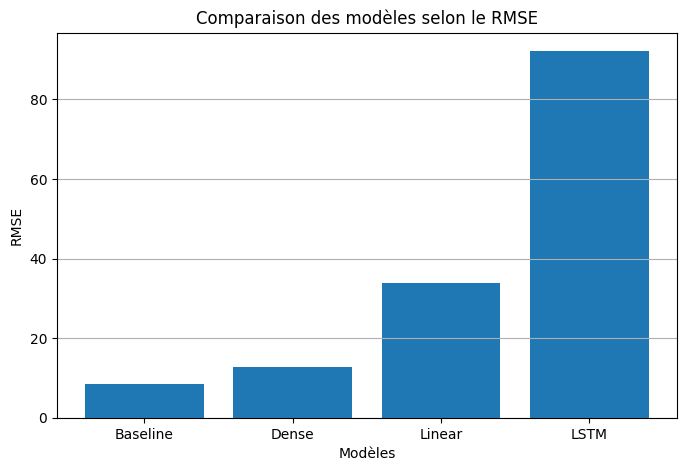

In [695]:

plt.figure(figsize=(8, 5))
plt.bar(results_models["model"], results_models["rmse"])
plt.title("Comparaison des modèles selon le RMSE")
plt.xlabel("Modèles")
plt.ylabel("RMSE")
plt.grid(axis="y")
plt.show()

La figure suivante présente une comparaison des différents modèles selon la métrique RMSE (Root Mean Squared Error). Cette métrique mesure l’écart moyen entre les valeurs réelles et les valeurs prédites par le modèle, en pénalisant davantage les erreurs importantes. On observe clairement que le modèle Baseline obtient la valeur de RMSE la plus faible, ce qui indique qu’il réalise les prédictions les plus proches des données réelles. À l’inverse, les modèles Dense, Linear et surtout LSTM présentent des erreurs plus élevées. Cette visualisation confirme donc les résultats obtenus précédemment dans le tableau de comparaison et montre que, pour ce dataset, le modèle baseline reste le plus performant.

# Valeurs réelles vs valeurs prédites

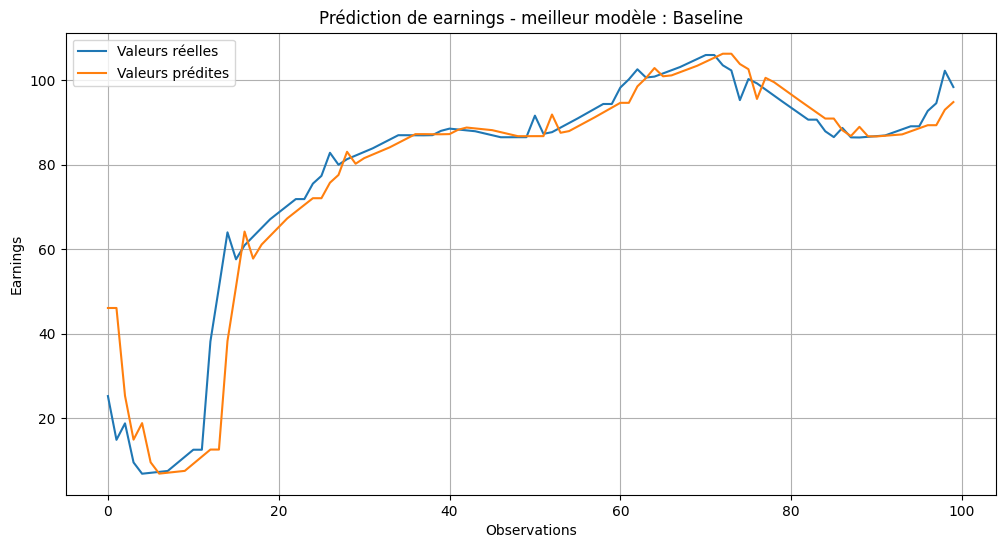

In [696]:


plt.figure(figsize=FIGSIZE)
plt.plot(best_prediction_result["y_test_real"][:100], label="Valeurs réelles")
plt.plot(best_prediction_result["y_pred_real"][:100], label="Valeurs prédites")
plt.title(f"Prédiction de earnings - meilleur modèle : {best_model_name}")
plt.xlabel("Observations")
plt.ylabel("Earnings")
plt.legend()
plt.grid(True)
plt.show()

La figure suivante compare les valeurs réelles des earnings avec les valeurs prédites par le meilleur modèle identifié précédemment, ici le modèle Baseline. On observe que les deux courbes suivent globalement une évolution très similaire au fil des observations. Cela signifie que le modèle parvient à reproduire correctement la tendance générale de la série temporelle. Bien que certaines petites différences apparaissent entre les valeurs réelles et les prédictions, l’écart reste globalement limité, ce qui confirme les bonnes performances observées précédemment avec les métriques MAE, RMSE et (R^2). Cette visualisation permet ainsi de vérifier visuellement que les prédictions du modèle restent proches des données réelles.

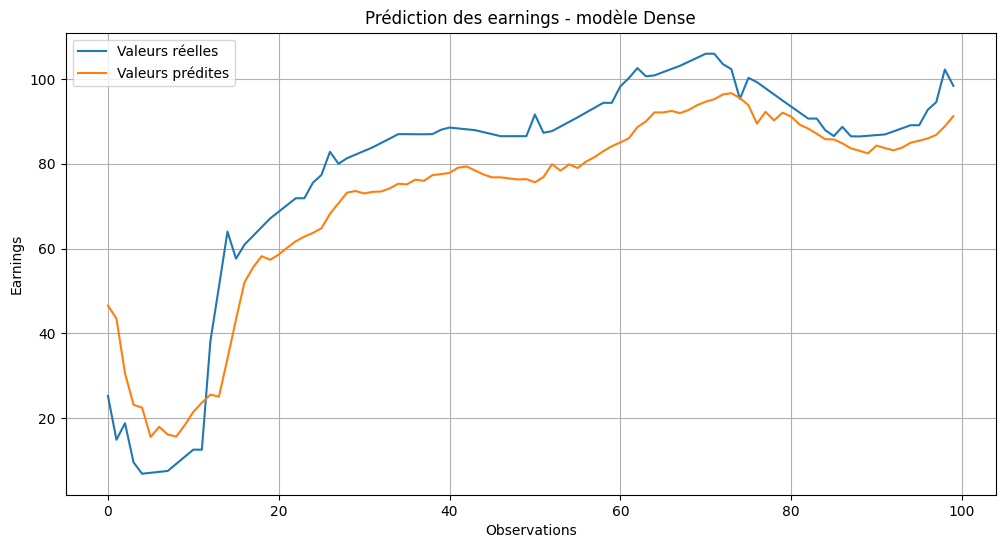

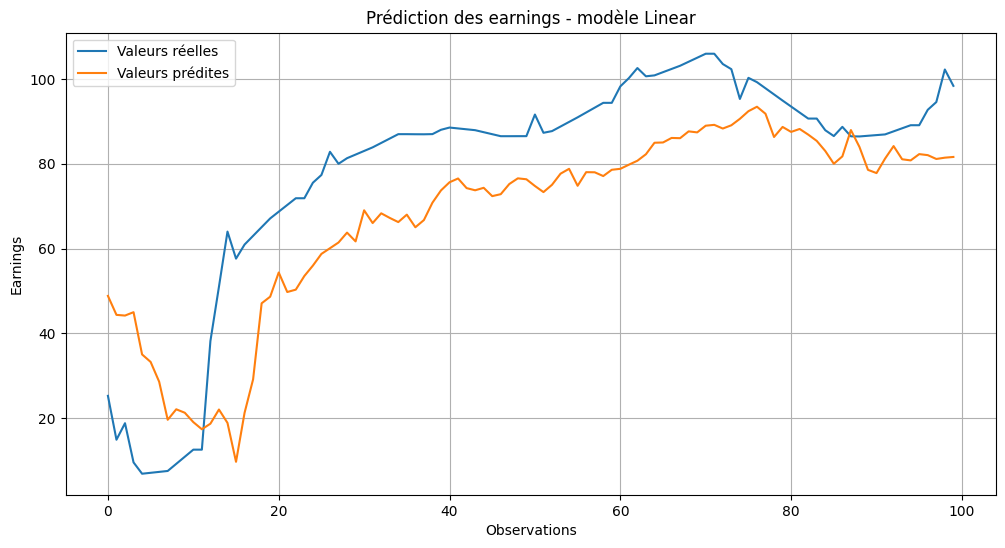

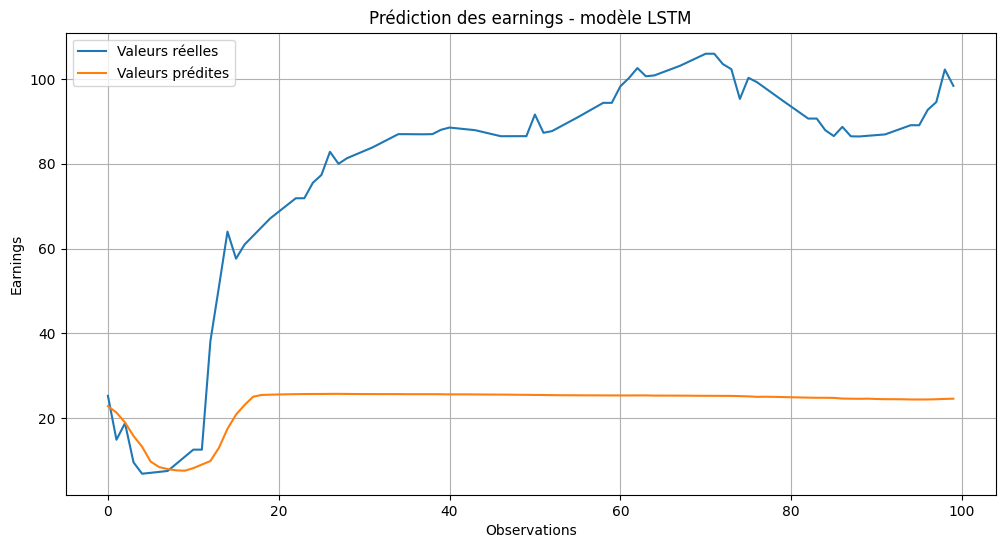

In [697]:
# VISUALISATION DES PREDICTIONS DES AUTRES MODELES

models_to_plot = ["Dense", "Linear", "LSTM"]

for model_name in models_to_plot:

    model = models[model_name]

    res = train_and_evaluate(
        model,
        x_train, y_train,
        x_val, y_val,
        x_test, y_test,
        mean, std,
        target_col
    )

    y_true = res["y_test_real"]
    y_pred = res["y_pred_real"]

    plt.figure(figsize=FIGSIZE)
    plt.plot(y_true[:100], label="Valeurs réelles")
    plt.plot(y_pred[:100], label="Valeurs prédites")
    plt.title(f"Prédiction des earnings - modèle {model_name}")
    plt.xlabel("Observations")
    plt.ylabel("Earnings")
    plt.legend()
    plt.grid(True)
    plt.show()

Les figures précédentes présentent une comparaison entre les valeurs réelles des earnings et les valeurs prédites par les différents modèles de deep learning testés, à savoir les modèles Dense, Linear et LSTM. On observe que, bien que certains modèles parviennent à suivre partiellement la tendance générale de la série temporelle, les prédictions restent globalement moins précises que celles du modèle baseline. Le modèle Dense et le modèle Linear capturent relativement bien la tendance globale mais présentent des écarts visibles par rapport aux valeurs réelles. Le modèle LSTM, quant à lui, montre des prédictions beaucoup plus éloignées de la série réelle, ce qui confirme les métriques obtenues précédemment. Ces visualisations illustrent donc que, dans ce cas précis, les architectures plus complexes ne permettent pas d’améliorer la qualité des prédictions par rapport à l’approche baseline.

# Courbe d apprentissage

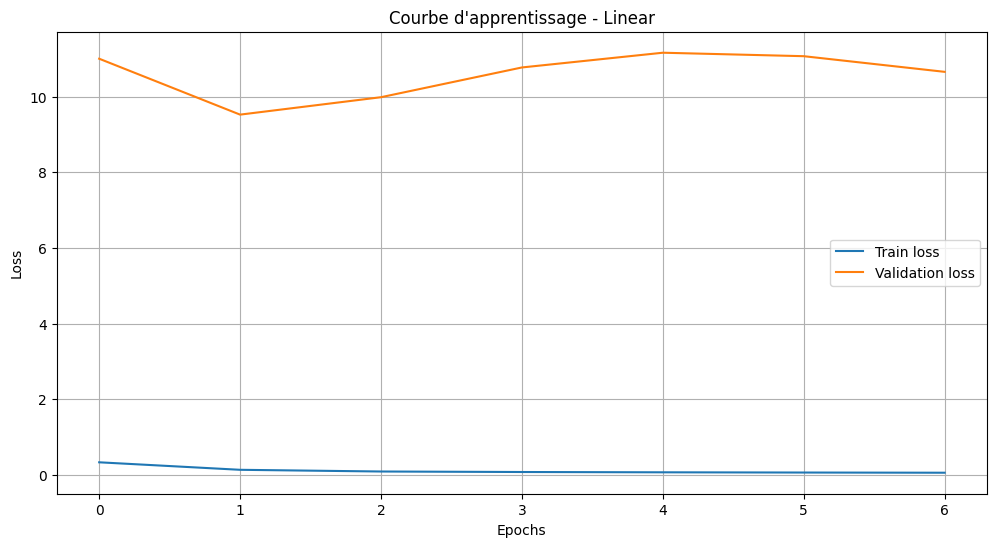

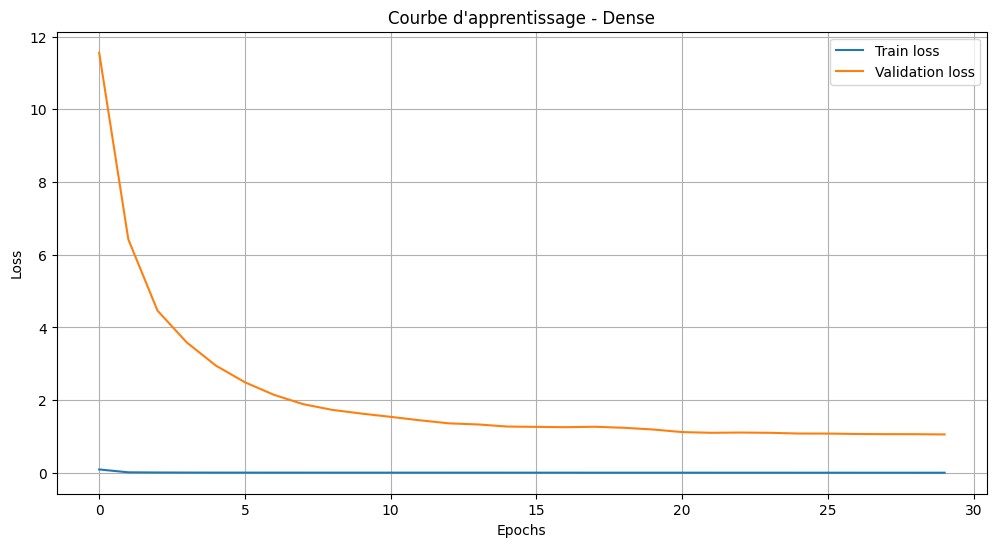

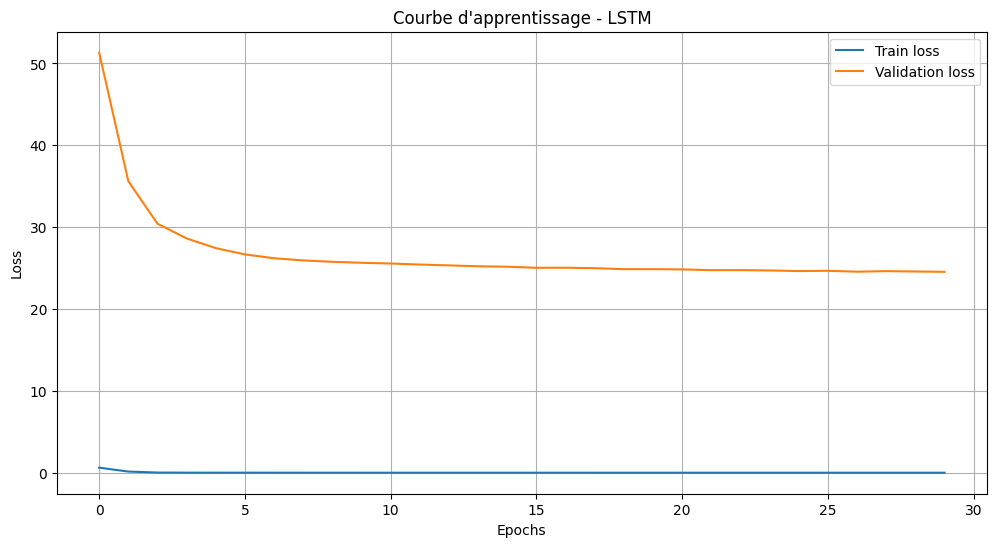

In [698]:

for model_name, history in history_dict.items():
    plt.figure(figsize=FIGSIZE)
    plt.plot(history.history["loss"], label="Train loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.title(f"Courbe d'apprentissage - {model_name}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

Les figures suivantes présentent les courbes d’apprentissage des différents modèles testés. Elles permettent de comparer l’évolution de la perte (loss) sur les données d’entraînement et sur les données de validation au cours des différentes époques.

Dans ces graphiques, la ligne bleue représente la loss sur le jeu d’entraînement (train loss), c’est-à-dire l’erreur du modèle sur les données qu’il utilise pour apprendre. La ligne orange correspond à la loss sur le jeu de validation (validation loss).

Le jeu de validation est une partie des données qui n’est pas utilisée pour entraîner directement le modèle. Il sert à vérifier pendant l’apprentissage si le modèle est capable de bien généraliser à de nouvelles données qu’il n’a jamais vues.

Au cours de l’entraînement, on s’attend généralement à ce que la loss d’entraînement diminue progressivement, ce qui signifie que le modèle apprend à mieux ajuster les données. Si la courbe de validation diminue également et reste proche de la courbe d’entraînement, cela indique que le modèle généralise correctement aux nouvelles données.

Cependant, dans notre cas, on observe que pour les trois modèles testés (Linear, Dense et LSTM), la perte d’entraînement diminue très rapidement et reste proche de zéro, alors que la perte de validation reste nettement plus élevée. Cet écart important entre les deux courbes indique un phénomène appelé surapprentissage (overfitting).

L’overfitting correspond à une situation où le modèle s’adapte trop précisément aux données d’entraînement et apprend même le bruit ou les variations spécifiques du dataset. Dans ce cas, le modèle fonctionne très bien sur les données qu’il a vues pendant l’entraînement, mais il devient moins performant pour prédire de nouvelles données.

Cette observation explique en partie pourquoi ces modèles obtiennent des performances plus faibles sur le jeu de test et confirme les résultats observés précédemment lors de la comparaison des métriques et des prédictions.

Il est également important de noter que le modèle baseline n’apparaît pas dans ces courbes d’apprentissage. En effet, contrairement aux autres modèles, le baseline ne nécessite pas de phase d’entraînement. Il repose simplement sur une règle très simple : prédire que la valeur future des earnings sera égale à la valeur actuelle. Comme il n’y a pas de processus d’apprentissage avec des époques et une fonction de perte à minimiser, il n’existe pas de courbes de train loss ou de validation loss associées à ce modèle. C’est pourquoi seules les architectures entraînées (Linear, Dense et LSTM) apparaissent dans ces graphiques.

## EXTENSION DU MODELEAVEC DES VARIABLES MACROECONOMIQUEPartie2

Dans la première partie du projet, les modèles ont été entraînés uniquement à partir de variables financières issues de l’indice S&P500 et de ses composantes. Dans cette seconde partie, nous étendons l’analyse en intégrant de nouvelles variables économiques provenant d’autres tables de la base de données, notamment l’inflation, le Big Mac Index et la performance du Bitcoin. L’objectif est d’évaluer si l’ajout de ces indicateurs économiques permet d’améliorer la capacité de prédiction des modèles.

# Importation des nouvelles tables 

In [699]:
bdd = mysql.connector.connect(**config)

sp2 = pd.read_sql("""
SELECT observation_date,
       sp500,
       dividend,
       earnings,
       longInterestRate,
       realPrice,
       realDividend,
       realEarnings
FROM standardandpoor
""", bdd)

bigmac = pd.read_sql("""
SELECT observation_date,
       dollar_price
FROM bigmacindex
""", bdd)

inflation = pd.read_sql("""
SELECT observation_date,
       CPI
FROM inflation
""", bdd)

bitcoin = pd.read_sql("""
SELECT observation_date,
       Adj_Close
FROM bitcoinperformance
""", bdd)

bdd.close()

print("standardandpoor :", sp2.shape)
print("bigmacindex     :", bigmac.shape)
print("inflation       :", inflation.shape)
print("bitcoin         :", bitcoin.shape)

standardandpoor : (1833, 8)
bigmacindex     : (8126, 2)
inflation       : (1297, 2)
bitcoin         : (3413, 2)


Dans cette étape, nous importons les différentes tables nécessaires au projet depuis la base de données MySQL en utilisant la bibliothèque pandas. Chaque table contient des informations économiques ou financières qui seront utilisées dans l’analyse.

La table standardandpoor constitue la base principale du dataset. Elle contient plusieurs variables financières importantes comme l’indice S&P 500, les dividendes, les earnings ainsi que d’autres indicateurs comme les prix réels, les dividendes réels et les earnings réels.

Ensuite, nous importons d’autres tables afin d’ajouter des variables macroéconomiques au dataset. La table bigmacindex contient le prix du Big Mac en dollars, qui est parfois utilisé comme indicateur du pouvoir d’achat. La table inflation contient l’indice des prix à la consommation (CPI), qui permet de mesurer l’inflation. Enfin, la table bitcoinperformance fournit le prix ajusté du Bitcoin, ce qui permet d’ajouter une information liée au marché des cryptomonnaies.

Toutes ces tables sont chargées dans des DataFrames pandas, ce qui permet de manipuler facilement les données dans le notebook. Dans les étapes suivantes, ces différentes sources seront fusionnées afin de créer un dataset plus complet et d’étudier si l’ajout de variables macroéconomiques peut améliorer la prédiction des earnings.

# Preparation  des dates et agragations

In [700]:

# Standard & Poor
sp2 = sp2.rename(columns={"observation_date": "date"})
sp2["date"] = pd.to_datetime(sp2["date"], errors="coerce")
sp2 = sp2.dropna(subset=["date"]).copy()
sp2 = sp2.sort_values("date").reset_index(drop=True)
sp2["year_month"] = sp2["date"].dt.to_period("M")

# Big Mac Index
bigmac = bigmac.rename(columns={"observation_date": "date"})
bigmac["date"] = pd.to_datetime(bigmac["date"], errors="coerce")
bigmac = bigmac.dropna(subset=["date"]).copy()
bigmac["year_month"] = bigmac["date"].dt.to_period("M")

bigmac_monthly = (
    bigmac.groupby("year_month", as_index=False)["dollar_price"]
    .mean()
    .rename(columns={"dollar_price": "bigmac_price"})
)

# Inflation
inflation = inflation.rename(columns={"observation_date": "date"})
inflation["date"] = pd.to_datetime(inflation["date"], errors="coerce")
inflation = inflation.dropna(subset=["date"]).copy()
inflation["year_month"] = inflation["date"].dt.to_period("M")

inflation_monthly = (
    inflation.groupby("year_month", as_index=False)["CPI"]
    .mean()
    .rename(columns={"CPI": "inflation_cpi"})
)

# Bitcoin
bitcoin = bitcoin.rename(columns={"observation_date": "date"})
bitcoin["date"] = pd.to_datetime(bitcoin["date"], errors="coerce")
bitcoin = bitcoin.dropna(subset=["date"]).copy()
bitcoin["year_month"] = bitcoin["date"].dt.to_period("M")

bitcoin_monthly = (
    bitcoin.groupby("year_month", as_index=False)["Adj_Close"]
    .mean()
    .rename(columns={"Adj_Close": "bitcoin_adj_close"})
)

print("sp2 shape              :", sp2.shape)
print("bigmac_monthly shape   :", bigmac_monthly.shape)
print("inflation_monthly shape:", inflation_monthly.shape)
print("bitcoin_monthly shape  :", bitcoin_monthly.shape)

display(bigmac_monthly.head())
display(inflation_monthly.head())
display(bitcoin_monthly.head())

sp2 shape              : (1833, 9)
bigmac_monthly shape   : (268, 2)
inflation_monthly shape: (1297, 2)
bitcoin_monthly shape  : (113, 2)


,year_month,bigmac_price
0,2000-04,2.32393
1,2000-05,2.32393
2,2000-06,2.32393
3,2000-07,2.32393
4,2000-08,2.32393


,year_month,inflation_cpi
0,1913-01,9.8
1,1913-02,9.8
2,1913-03,9.8
3,1913-04,9.8
4,1913-05,9.8


,year_month,bitcoin_adj_close
0,2014-09,403.324613
1,2014-10,364.148873
2,2014-11,366.099799
3,2014-12,341.267871
4,2015-01,248.782547


# Fusion de tables

In [701]:
data_p2 = sp2.merge(bigmac_monthly, on="year_month", how="left")
data_p2 = data_p2.merge(inflation_monthly, on="year_month", how="left")
data_p2 = data_p2.merge(bitcoin_monthly, on="year_month", how="left")

print("Shape après fusion :", data_p2.shape)
display(data_p2.head())

Shape après fusion : (1833, 12)


,date,sp500,dividend,earnings,longInterestRate,realPrice,realDividend,realEarnings,year_month,bigmac_price,inflation_cpi,bitcoin_adj_close
0,1871-01-01,4.515,0.26,0.4,5.335,111.325,6.41,9.86,1871-01,NaN,NaN,NaN
1,1871-02-01,4.500,0.26,0.4,5.320,107.250,6.20,9.53,1871-02,NaN,NaN,NaN
2,1871-03-01,4.610,0.26,0.4,5.330,108.270,6.11,9.39,1871-03,NaN,NaN,NaN
3,1871-04-01,4.740,0.26,0.4,5.330,115.540,6.34,9.75,1871-04,NaN,NaN,NaN
4,1871-05-01,4.860,0.26,0.4,5.330,121.220,6.48,9.98,1871-05,NaN,NaN,NaN


# Creation de la variable cible

In [702]:

data_p2["target_earnings_next"] = data_p2["earnings"].shift(-1)

# on remplit les valeurs manquantes pour éviter de perdre trop de données
data_p2 = data_p2.ffill()
data_p2 = data_p2.bfill()

# on supprime seulement la dernière ligne (à cause du shift)
data_p2 = data_p2.iloc[:-1].reset_index(drop=True)

print("Shape final Partie 2 :", data_p2.shape)
print("Période couverte :", data_p2["date"].min(), "->", data_p2["date"].max())

display(data_p2.head())

Shape final Partie 2 : (1832, 13)
Période couverte : 1871-01-01 00:00:00 -> 2023-08-01 00:00:00


,date,sp500,dividend,earnings,longInterestRate,realPrice,realDividend,realEarnings,year_month,bigmac_price,inflation_cpi,bitcoin_adj_close,target_earnings_next
0,1871-01-01,4.515,0.26,0.4,5.335,111.325,6.41,9.86,1871-01,2.32393,9.8,403.324613,0.4
1,1871-02-01,4.500,0.26,0.4,5.320,107.250,6.20,9.53,1871-02,2.32393,9.8,403.324613,0.4
2,1871-03-01,4.610,0.26,0.4,5.330,108.270,6.11,9.39,1871-03,2.32393,9.8,403.324613,0.4
3,1871-04-01,4.740,0.26,0.4,5.330,115.540,6.34,9.75,1871-04,2.32393,9.8,403.324613,0.4
4,1871-05-01,4.860,0.26,0.4,5.330,121.220,6.48,9.98,1871-05,2.32393,9.8,403.324613,0.4


Dans cette seconde partie, les données financières sont enrichies avec de nouvelles variables macroéconomiques. Le Big Mac Index est utilisé comme indicateur indirect du pouvoir d’achat, l’inflation reflète l’évolution générale des prix, et le Bitcoin introduit une information supplémentaire sur un marché financier alternatif. Comme ces tables n’ont pas exactement la même fréquence temporelle, les données sont agrégées au niveau mensuel avant d’être fusionnées avec la table principale. Cette étape permet de construire un nouveau dataset plus riche afin de tester si l’ajout de variables économiques améliore la précision des prédictions.

# Nouvelles variables 

In [703]:
target_col_p2 = "target_earnings_next"

features_p2 = [
    "sp500",
    "dividend",
    "earnings",
    "longInterestRate",
    "realPrice",
    "realDividend",
    "realEarnings",
    "bigmac_price",
    "inflation_cpi",
    "bitcoin_adj_close"
]

df_model_p2 = data_p2[features_p2 + [target_col_p2]].copy()
df_model_p2 = df_model_p2.reset_index(drop=True)

print("Colonnes utilisées en Partie 2 :")
print(df_model_p2.columns.tolist())

print("Nombre de lignes :", len(df_model_p2))

display(df_model_p2.head())

Colonnes utilisées en Partie 2 :
['sp500', 'dividend', 'earnings', 'longInterestRate', 'realPrice', 'realDividend', 'realEarnings', 'bigmac_price', 'inflation_cpi', 'bitcoin_adj_close', 'target_earnings_next']
Nombre de lignes : 1832


,sp500,dividend,earnings,longInterestRate,realPrice,realDividend,realEarnings,bigmac_price,inflation_cpi,bitcoin_adj_close,target_earnings_next
0,4.515,0.26,0.4,5.335,111.325,6.41,9.86,2.32393,9.8,403.324613,0.4
1,4.500,0.26,0.4,5.320,107.250,6.20,9.53,2.32393,9.8,403.324613,0.4
2,4.610,0.26,0.4,5.330,108.270,6.11,9.39,2.32393,9.8,403.324613,0.4
3,4.740,0.26,0.4,5.330,115.540,6.34,9.75,2.32393,9.8,403.324613,0.4
4,4.860,0.26,0.4,5.330,121.220,6.48,9.98,2.32393,9.8,403.324613,0.4


Nous définissons la liste des variables explicatives dans features_p2. Ces variables incluent les indicateurs financiers déjà utilisés dans la première partie du projet, comme le S&P 500, les dividendes, les earnings, le taux d’intérêt à long terme, ainsi que les valeurs réelles des prix et des dividendes. À ces variables s’ajoutent maintenant de nouvelles variables macroéconomiques introduites dans cette deuxième partie, comme le prix du Big Mac, l’inflation (CPI) et le prix du Bitcoin ajusté.

Toutes ces variables sont ensuite regroupées dans un nouveau DataFrame df_model_p2, qui contient uniquement les colonnes nécessaires pour l’entraînement des modèles. Cela permet de préparer un dataset propre et structuré pour les étapes suivantes, notamment la normalisation des données, la création des fenêtres temporelles et l’entraînement des modèles de prédiction.

# Matrice de correlation

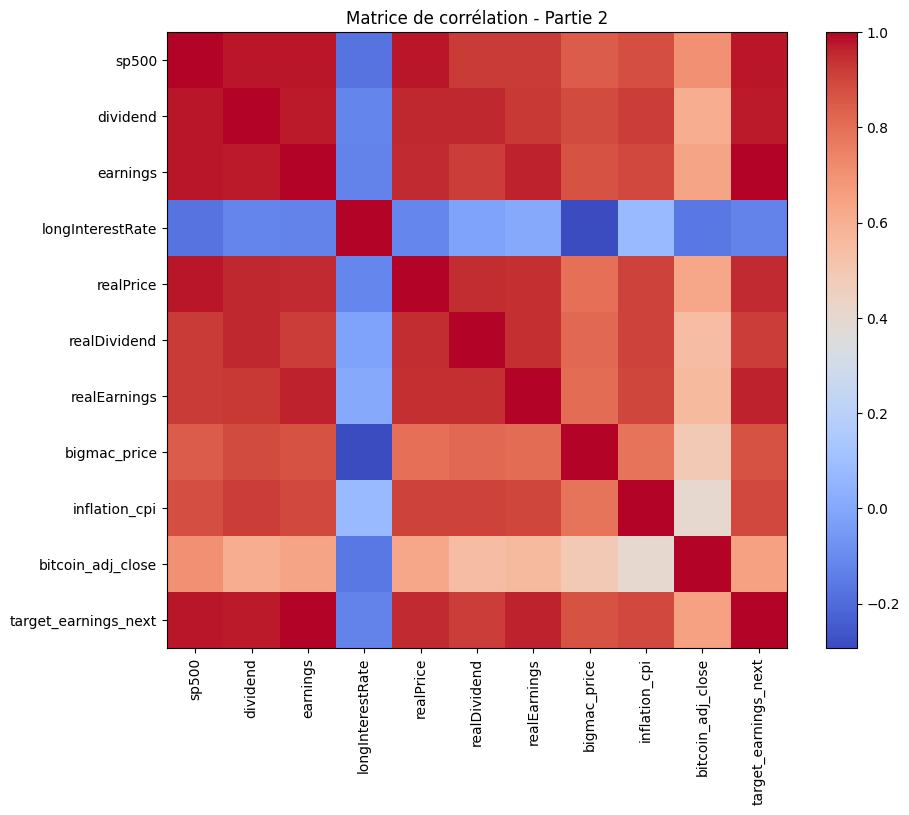

,sp500,dividend,earnings,longInterestRate,realPrice,realDividend,realEarnings,bigmac_price,inflation_cpi,bitcoin_adj_close,target_earnings_next
sp500,1.000000,0.979141,0.974785,-0.175923,0.976388,0.919708,0.919835,0.845300,0.874107,0.704078,0.975198
dividend,0.979141,1.000000,0.971329,-0.117346,0.958761,0.955773,0.927624,0.884720,0.917652,0.606510,0.970604
earnings,0.974785,0.971329,1.000000,-0.122942,0.950448,0.916917,0.961970,0.872597,0.890491,0.640939,0.998036
longInterestRate,-0.175923,-0.117346,-0.122942,1.000000,-0.114560,-0.016527,0.006143,-0.293290,0.079520,-0.158513,-0.123807
realPrice,0.976388,0.958761,0.950448,-0.114560,1.000000,0.946717,0.941572,0.794770,0.905974,0.627568,0.950902
realDividend,0.919708,0.955773,0.916917,-0.016527,0.946717,1.000000,0.943417,0.817211,0.904023,0.540708,0.916093
realEarnings,0.919835,0.927624,0.961970,0.006143,0.941572,0.943417,1.000000,0.805121,0.898296,0.559239,0.959851
bigmac_price,0.845300,0.884720,0.872597,-0.293290,0.794770,0.817211,0.805121,1.000000,0.784708,0.486168,0.872249
inflation_cpi,0.874107,0.917652,0.890491,0.079520,0.905974,0.904023,0.898296,0.784708,1.000000,0.399082,0.890442
bitcoin_adj_close,0.704078,0.606510,0.640939,-0.158513,0.627568,0.540708,0.559239,0.486168,0.399082,1.000000,0.648245


In [704]:
corr_p2 = df_model_p2.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_p2, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_p2.columns)), corr_p2.columns, rotation=90)
plt.yticks(range(len(corr_p2.columns)), corr_p2.columns)
plt.title("Matrice de corrélation - Partie 2")
plt.show()

display(corr_p2)

Certaines variables macroéconomiques ajoutées dans cette deuxième partie présentent des corrélations plus faibles avec les autres variables. Par exemple, bitcoin_adj_close et inflation_cpi semblent avoir une relation moins forte avec les variables financières principales. Cela suggère que leur influence sur la prédiction des earnings pourrait être plus limitée ou indirecte.

Enfin, on remarque que longInterestRate présente même des corrélations légèrement négatives avec plusieurs variables financières. Cela peut s’expliquer par le fait que les taux d’intérêt élevés peuvent parfois être associés à un ralentissement économique ou à une pression sur les marchés financiers.

Dans l’ensemble, cette matrice de corrélation permet de mieux comprendre la structure des données et de vérifier que certaines variables peuvent effectivement apporter de l’information utile pour la prédiction des earnings.

# Standarisation

In [705]:
df_scaled_p2, mean_p2, std_p2 = standardize_with_train_stats(df_model_p2)

print("Shape de df_scaled_p2 :", df_scaled_p2.shape)
display(df_scaled_p2.head())

Shape de df_scaled_p2 : (1832, 11)


,sp500,dividend,earnings,longInterestRate,realPrice,realDividend,realEarnings,bigmac_price,inflation_cpi,bitcoin_adj_close,target_earnings_next
0,-0.553415,-0.597148,-0.592173,0.289475,-1.105990,-1.445225,-1.138339,-0.999659,-0.614154,0.999659,-0.5929
1,-0.553602,-0.597148,-0.592173,0.283229,-1.124542,-1.480458,-1.161246,-0.999659,-0.614154,0.999659,-0.5929
2,-0.552231,-0.597148,-0.592173,0.287393,-1.119898,-1.495557,-1.170964,-0.999659,-0.614154,0.999659,-0.5929
3,-0.550612,-0.597148,-0.592173,0.287393,-1.086800,-1.456969,-1.145975,-0.999659,-0.614154,0.999659,-0.5929
4,-0.549117,-0.597148,-0.592173,0.287393,-1.060941,-1.433481,-1.130010,-0.999659,-0.614154,0.999659,-0.5929


# Window generator

In [706]:

wg_p2 = WindowGenerator(
    df=df_scaled_p2,
    input_width=INPUT_WIDTH,
    shift=SHIFT,
    p_val_df=P_VAL,
    p_test_df=P_TEST,
    label_width=LABEL_WIDTH
)

print("----- Taille des sous-ensembles -----")
print("train_df :", wg_p2.training_df.shape)
print("val_df   :", wg_p2.val_df.shape)
print("test_df  :", wg_p2.test_df.shape)

print("\n----- Shapes des fenêtres -----")
print("training_input :", wg_p2.training_input.shape)
print("training_label :", wg_p2.training_label.shape)
print("val_input      :", wg_p2.val_input.shape)
print("val_label      :", wg_p2.val_label.shape)
print("test_input     :", wg_p2.test_input.shape)
print("test_label     :", wg_p2.test_label.shape)

----- Taille des sous-ensembles -----
train_df : (1465, 11)
val_df   : (183, 11)
test_df  : (184, 11)

----- Shapes des fenêtres -----
training_input : (1459, 5, 11)
training_label : (1459, 1, 11)
val_input      : (177, 5, 11)
val_label      : (177, 1, 11)
test_input     : (178, 5, 11)
test_label     : (178, 1, 11)


# X et Y 

In [707]:

x_train_p2 = wg_p2.training_input.astype(np.float32)
x_val_p2 = wg_p2.val_input.astype(np.float32)
x_test_p2 = wg_p2.test_input.astype(np.float32)

target_index_p2 = df_scaled_p2.columns.get_loc(target_col_p2)

y_train_p2 = extract_target_from_labels(wg_p2.training_label, target_index_p2)
y_val_p2 = extract_target_from_labels(wg_p2.val_label, target_index_p2)
y_test_p2 = extract_target_from_labels(wg_p2.test_label, target_index_p2)

print("----- Shapes finales -----")
print("x_train_p2 :", x_train_p2.shape)
print("y_train_p2 :", y_train_p2.shape)
print("x_val_p2   :", x_val_p2.shape)
print("y_val_p2   :", y_val_p2.shape)
print("x_test_p2  :", x_test_p2.shape)
print("y_test_p2  :", y_test_p2.shape)

----- Shapes finales -----
x_train_p2 : (1459, 5, 11)
y_train_p2 : (1459, 1)
x_val_p2   : (177, 5, 11)
y_val_p2   : (177, 1)
x_test_p2  : (178, 5, 11)
y_test_p2  : (178, 1)


# Basline 

In [708]:
earnings_index_p2 = df_scaled_p2.columns.get_loc("target_earnings_next")

baseline_pred_scaled_p2 = x_test_p2[:, -1, earnings_index_p2].reshape(-1, 1)

y_test_real_baseline_p2 = inverse_transform_target(y_test_p2, mean_p2, std_p2, target_col_p2)
y_pred_real_baseline_p2 = inverse_transform_target(baseline_pred_scaled_p2, mean_p2, std_p2, target_col_p2)

y_test_real_baseline_p2 = np.array(y_test_real_baseline_p2).reshape(-1)
y_pred_real_baseline_p2 = np.array(y_pred_real_baseline_p2).reshape(-1)

baseline_mae_p2, baseline_rmse_p2, baseline_r2_p2 = evaluate_model(
    y_test_real_baseline_p2,
    y_pred_real_baseline_p2
)

print("Résultats baseline - Partie 2 :")
print("MAE  :", baseline_mae_p2)
print("RMSE :", baseline_rmse_p2)
print("R²   :", baseline_r2_p2)

Résultats baseline - Partie 2 :
MAE  : 3.1968270870161675
RMSE : 6.52712680787797
R²   : 0.9771475580271621


# Modeles

In [709]:
models_p2 = {
    "Linear": build_linear_model(x_train_p2.shape[1:]),
    "Dense": build_dense_model(x_train_p2.shape[1:]),
    "LSTM": build_lstm_model(x_train_p2.shape[1:])
}

# Comparaison

In [710]:

results_models_p2 = []
history_dict_p2 = {}
predictions_store_p2 = {}

# baseline
results_models_p2.append({
    "model": "Baseline",
    "mae": baseline_mae_p2,
    "rmse": baseline_rmse_p2,
    "r2": baseline_r2_p2
})

predictions_store_p2["Baseline"] = {
    "y_test_real": y_test_real_baseline_p2,
    "y_pred_real": y_pred_real_baseline_p2
}

best_model_name_p2 = "Baseline"
best_prediction_result_p2 = {
    "y_test_real": y_test_real_baseline_p2,
    "y_pred_real": y_pred_real_baseline_p2
}
best_rmse_p2 = baseline_rmse_p2

print("==============================")
print("COMPARAISON DES MODELES - PARTIE 2")
print("==============================")

for model_name, model in models_p2.items():
    print(f"\nEntraînement du modèle : {model_name}")

    res = train_and_evaluate(
        model,
        x_train_p2, y_train_p2,
        x_val_p2, y_val_p2,
        x_test_p2, y_test_p2,
        mean_p2, std_p2,
        target_col_p2
    )

    results_models_p2.append({
        "model": model_name,
        "mae": res["mae"],
        "rmse": res["rmse"],
        "r2": res["r2"]
    })

    history_dict_p2[model_name] = res["history"]

    predictions_store_p2[model_name] = {
        "y_test_real": res["y_test_real"],
        "y_pred_real": res["y_pred_real"]
    }

    if res["rmse"] < best_rmse_p2:
        best_rmse_p2 = res["rmse"]
        best_model_name_p2 = model_name
        best_prediction_result_p2 = res

results_models_p2 = pd.DataFrame(results_models_p2).sort_values("rmse").reset_index(drop=True)

print("\nRésultats des modèles - Partie 2 :")
display(results_models_p2)

print("\nMeilleur modèle - Partie 2 :", best_model_name_p2)

COMPARAISON DES MODELES - PARTIE 2

Entraînement du modèle : Linear

Entraînement du modèle : Dense

Entraînement du modèle : LSTM

Résultats des modèles - Partie 2 :


,model,mae,rmse,r2
0,Baseline,3.196827e+00,6.527127e+00,9.771476e-01
1,LSTM,1.007690e+02,1.102362e+02,-5.518342e+00
2,Dense,3.197856e+16,6.807129e+16,-2.485516e+30
3,Linear,3.412805e+17,6.948282e+17,-2.589664e+32



Meilleur modèle - Partie 2 : Baseline


Le modèle Baseline obtient les meilleurs résultats parmi tous les modèles testés. Il présente une MAE d’environ 3.20 et une RMSE d’environ 6.53, ce qui indique que l’erreur moyenne de prédiction reste relativement faible. De plus, le R² est très proche de 1 (0.977), ce qui signifie que le modèle explique très bien la variance des données.

En revanche, les modèles LSTM, Dense et Linear donnent des résultats beaucoup moins satisfaisants. Le modèle LSTM présente des erreurs beaucoup plus élevées (MAE ≈ 101 et RMSE ≈ 110) et un R² négatif, ce qui indique que ses prédictions sont moins bonnes qu’un modèle trivial.

Les modèles Dense et Linear montrent des valeurs d’erreur extrêmement grandes , ainsi que des R² très négatifs, ce qui suggère un problème d’apprentissage ou de mise à l’échelle des données. Cela signifie que ces modèles ne parviennent pas à capturer correctement la relation entre les variables.

Ainsi, selon ces résultats, le modèle Baseline est le meilleur modèle pour cette partie, car il minimise les erreurs et explique correctement les données, contrairement aux autres modèles qui présentent des performances très faibles.

# Grafic RMSE

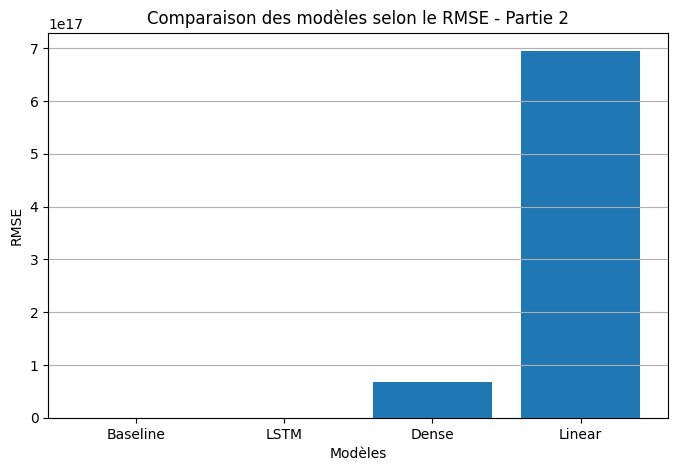

In [711]:

plt.figure(figsize=(8, 5))
plt.bar(results_models_p2["model"], results_models_p2["rmse"])
plt.title("Comparaison des modèles selon le RMSE - Partie 2")
plt.xlabel("Modèles")
plt.ylabel("RMSE")
plt.grid(axis="y")
plt.show()

On observe que le modèle Baseline possède le RMSE le plus faible, ce qui confirme qu’il est le modèle le plus performant dans cette comparaison. Ses prédictions sont donc les plus proches des valeurs réelles.

Le modèle LSTM présente un RMSE plus élevé que le Baseline, ce qui indique des erreurs de prédiction plus importantes. Ses performances sont donc moins bonnes dans ce cas.

Les modèles Dense et Linear montrent des valeurs de RMSE extrêmement élevées, très supérieures aux autres modèles. Cela signifie que leurs prédictions sont très éloignées des valeurs réelles. Ces résultats peuvent indiquer un problème d’entraînement du modèle, de normalisation des données ou de configuration du modèle.

Ainsi, ce graphique confirme que le modèle Baseline est le plus efficace parmi les modèles testés dans cette partie, tandis que les modèles Dense et Linear présentent des performances très faibles.

# Meilleur model 

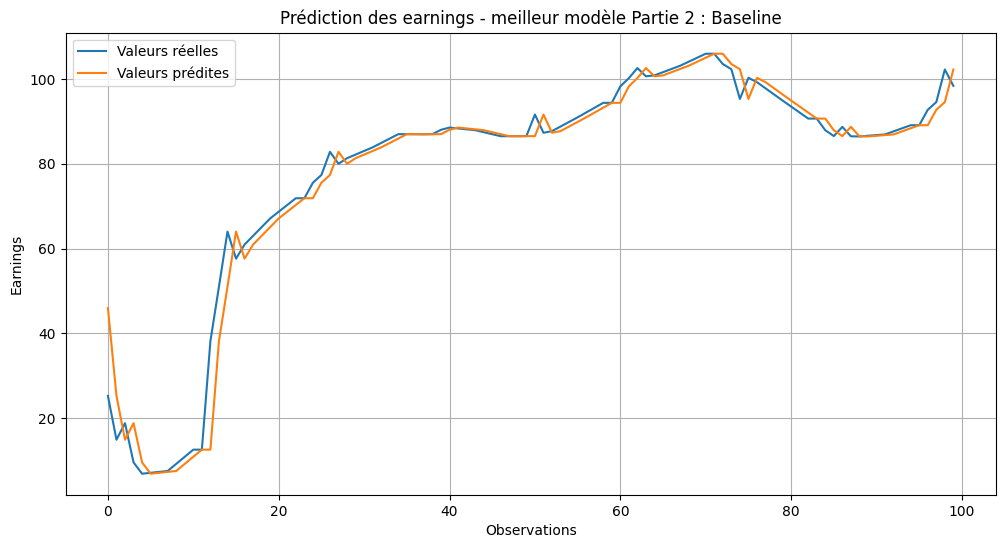

In [712]:


plt.figure(figsize=FIGSIZE)
plt.plot(best_prediction_result_p2["y_test_real"][:100], label="Valeurs réelles")
plt.plot(best_prediction_result_p2["y_pred_real"][:100], label="Valeurs prédites")
plt.title(f"Prédiction des earnings - meilleur modèle Partie 2 : {best_model_name_p2}")
plt.xlabel("Observations")
plt.ylabel("Earnings")
plt.legend()
plt.grid(True)
plt.show()

On observe que les valeurs prédites suivent globalement la même tendance que les valeurs réelles. Les deux courbes sont très proches l’une de l’autre sur la majorité des observations, ce qui indique que le modèle parvient à capturer correctement l’évolution des earnings.

Certaines petites différences entre les deux courbes apparaissent sur quelques observations, ce qui est normal dans un problème de prédiction. Ces écarts correspondent aux erreurs de prédiction du modèle, mais ils restent relativement limités.

Ainsi, ce graphique confirme que le modèle Baseline fournit des prédictions cohérentes et relativement proches des valeurs réelles, ce qui est cohérent avec les bons résultats obtenus précédemment avec les métriques d’évaluation (MAE, RMSE et R^2).
En conclusion, le modèle Baseline semble bien adapté pour prédire les earnings dans ce contexte, car il reproduit correctement la tendance générale des données.

# Predictions de tous les modeles 

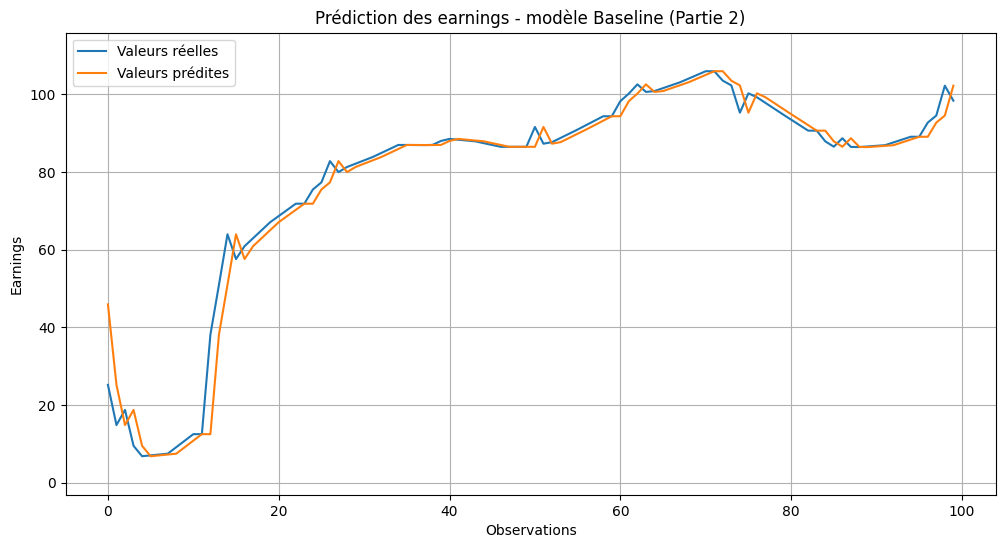

--- Baseline ---
Valeurs réelles  -> min : 6.860000062684046 max : 105.95999921384137
Valeurs prédites -> min : 6.860000062684046 max : 105.95999921384137



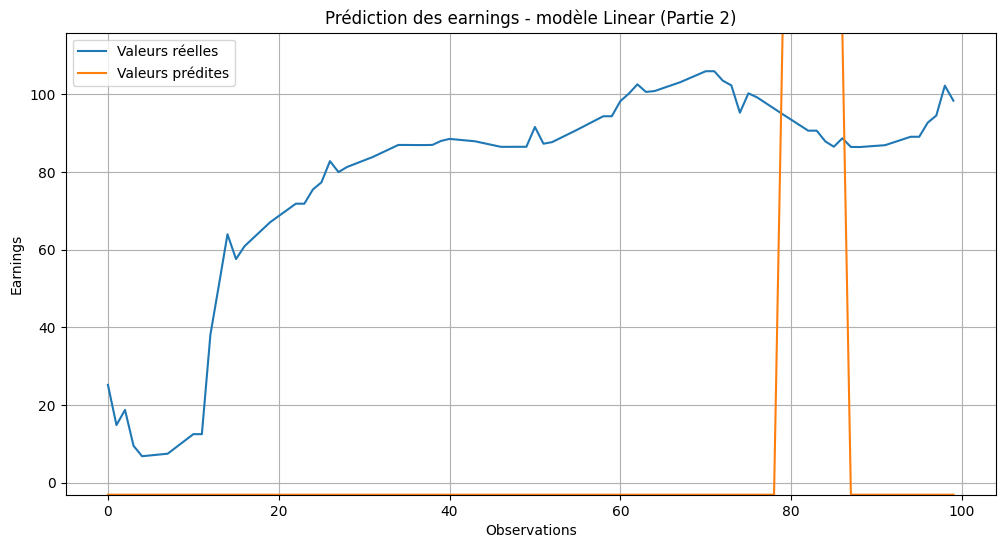

--- Linear ---
Valeurs réelles  -> min : 6.860000062684046 max : 105.95999921384137
Valeurs prédites -> min : -1.832693930583458e+16 max : 1806083346418673.8



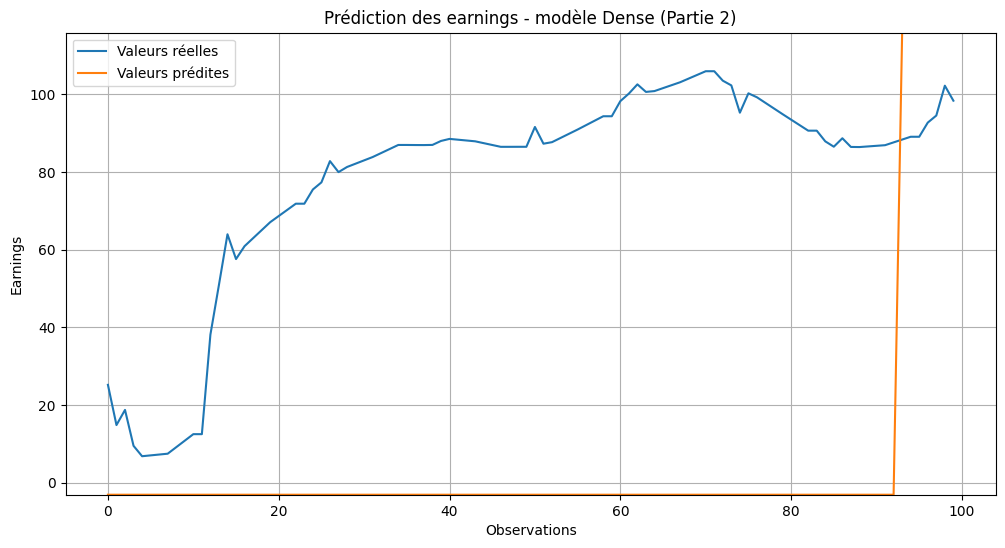

--- Dense ---
Valeurs réelles  -> min : 6.860000062684046 max : 105.95999921384137
Valeurs prédites -> min : -5005312956316192.0 max : 4502173438261890.5



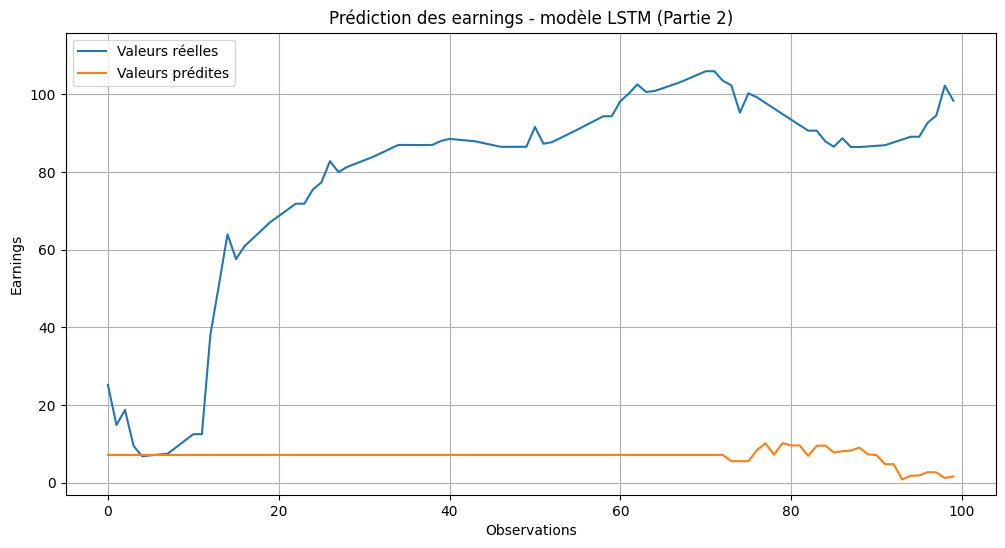

--- LSTM ---
Valeurs réelles  -> min : 6.860000062684046 max : 105.95999921384137
Valeurs prédites -> min : 0.8932860761956625 max : 10.226023388739208



In [ ]:

for model_name, pred_dict in predictions_store_p2.items():
    y_true = np.array(pred_dict["y_test_real"]).reshape(-1)[:100]
    y_pred = np.array(pred_dict["y_pred_real"]).reshape(-1)[:100]

    ymin = y_true.min()
    ymax = y_true.max()
    margin = (ymax - ymin) * 0.1
    if margin == 0:
        margin = 1

    lower = ymin - margin
    upper = ymax + margin

    # on coupe les prédictions trop extrêmes pour garder un graphique lisible
    y_pred_plot = np.clip(y_pred, lower, upper)

    plt.figure(figsize=FIGSIZE)
    plt.plot(y_true, label="Valeurs réelles")
    plt.plot(y_pred_plot, label="Valeurs prédites")
    plt.title(f"Prédiction des earnings - modèle {model_name} (Partie 2)")
    plt.xlabel("Observations")
    plt.ylabel("Earnings")
    plt.ylim(lower, upper)
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"--- {model_name} ---")
    print("Valeurs réelles  -> min :", y_true.min(), "max :", y_true.max())
    print("Valeurs prédites -> min :", y_pred.min(), "max :", y_pred.max())
    print()


On observe que le modèle Linear produit des prédictions très instables et parfois extrêmement élevées, très éloignées des valeurs réelles. Cela montre que la régression linéaire ne parvient pas à capturer correctement la relation entre les variables dans ce cas.

Le modèle Dense présente également de mauvaises performances. Les valeurs prédites restent presque constantes et ne suivent pas la variation des données réelles, ce qui indique que le modèle n’a pas réussi à apprendre correctement la structure des données.

De même, le modèle LSTM ne reproduit pas correctement la dynamique des earnings. Les prédictions restent très faibles et ne suivent pas l’évolution des valeurs réelles.

L’ajout de variables macroéconomiques ne garantit pas nécessairement une amélioration de la performance des modèles. Dans notre cas, certains modèles simples comme la régression linéaire deviennent instables et produisent des prédictions irréalistes. Cela suggère que l’augmentation du nombre de variables peut introduire des problèmes de multicolinéarité ou de sur-ajustement, rendant certains modèles moins robustes.

# Courbe d apprentissage

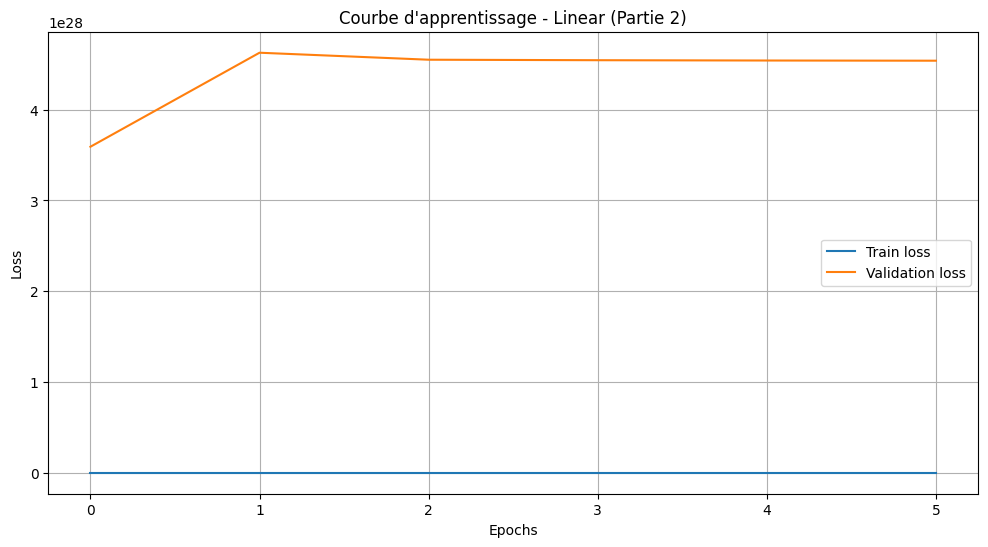

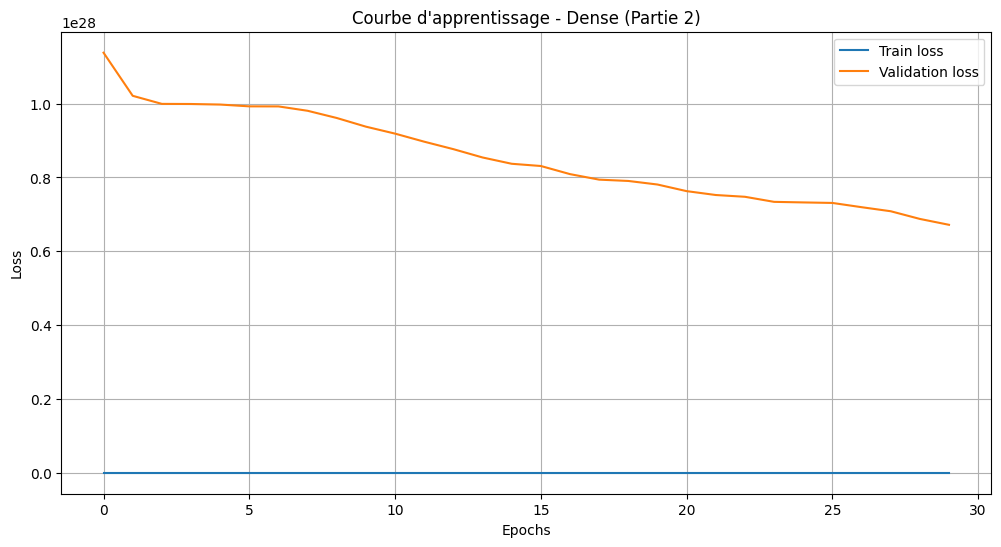

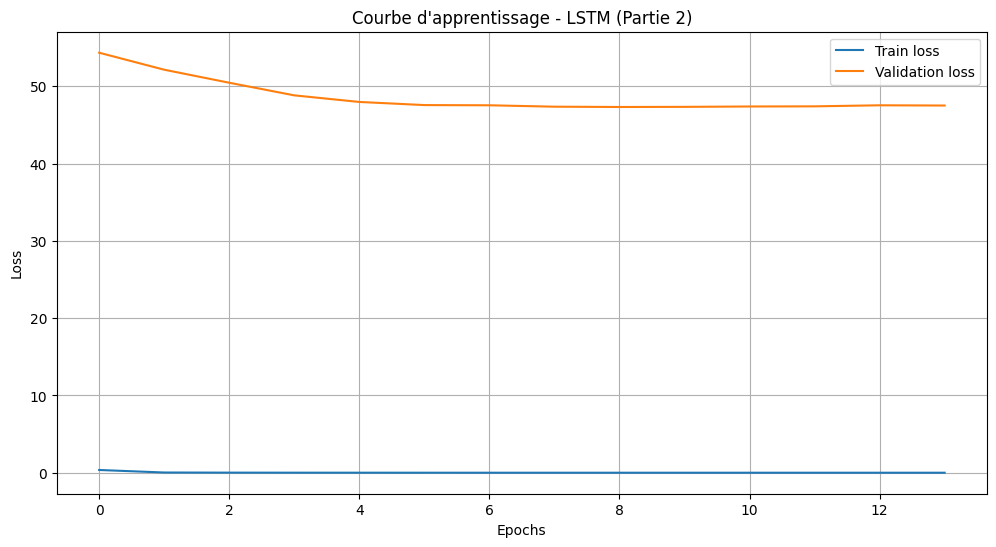

In [714]:

for model_name, history in history_dict_p2.items():
    plt.figure(figsize=FIGSIZE)
    plt.plot(history.history["loss"], label="Train loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.title(f"Courbe d'apprentissage - {model_name} (Partie 2)")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

# Tableau de comparaison PARTIE 1 ET PARTIE 2 

In [715]:

comparison_p1_p2 = pd.merge(
    results_models.rename(columns={
        "mae": "mae_part1",
        "rmse": "rmse_part1",
        "r2": "r2_part1"
    }),
    results_models_p2.rename(columns={
        "mae": "mae_part2",
        "rmse": "rmse_part2",
        "r2": "r2_part2"
    }),
    on="model",
    how="outer"
)

display(comparison_p1_p2)

,model,mae_part1,rmse_part1,r2_part1,mae_part2,rmse_part2,r2_part2
0,Baseline,4.868745,8.564801,0.960652,3.196827e+00,6.527127e+00,9.771476e-01
1,Dense,11.427832,12.690637,0.913612,3.197856e+16,6.807129e+16,-2.485516e+30
2,LSTM,82.616756,92.177766,-3.557649,1.007690e+02,1.102362e+02,-5.518342e+00
3,Linear,28.693932,33.780995,0.387884,3.412805e+17,6.948282e+17,-2.589664e+32


En observant les résultats (MAE, RMSE et R^2), on remarque que l’ajout des variables macroéconomiques n’a pas amélioré les performances des modèles. Le modèle Baseline reste le plus stable et le plus performant, avec des erreurs relativement faibles et un R^2 proche de 1. En revanche, les modèles Linear, Dense et LSTM deviennent beaucoup plus instables dans la partie 2, avec des erreurs très élevées et des valeurs de R^2 négatives. Cela signifie que les prédictions deviennent moins fiables lorsque l’on ajoute ces nouvelles variables.

Ces résultats suggèrent que l’ajout de variables macroéconomiques ne garantit pas nécessairement une meilleure précision des modèles. Dans notre cas, l’augmentation du nombre de variables peut introduire des problèmes comme la multicolinéarité ou le sur-ajustement, ce qui peut dégrader les performances de certains modèles au lieu de les améliorer.


# Visualisation

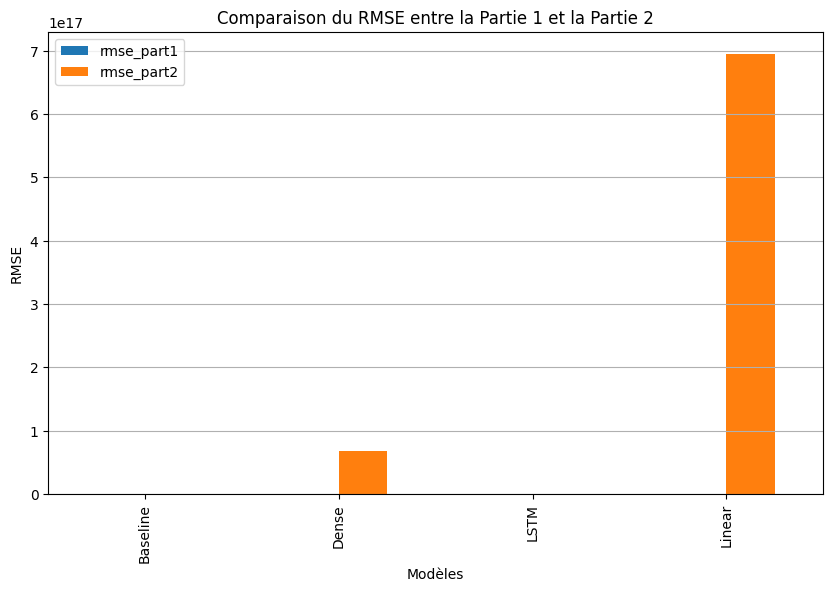

In [716]:

comparison_plot = comparison_p1_p2.set_index("model")[["rmse_part1", "rmse_part2"]]

comparison_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Comparaison du RMSE entre la Partie 1 et la Partie 2")
plt.xlabel("Modèles")
plt.ylabel("RMSE")
plt.grid(axis="y")
plt.show()

Dans ce graphique, nous comparons le RMSE des différents modèles entre la Partie 1 et la Partie 2. La Partie 1 utilise uniquement les variables principales liées aux données de l’entreprise, tandis que la Partie 2 inclut des variables macroéconomiques supplémentaires. On observe que le modèle Baseline reste relativement stable entre les deux parties, ce qui montre qu’il est robuste face à l’ajout de nouvelles variables. En revanche, les modèles Dense et Linear voient leur RMSE augmenter fortement dans la Partie 2, ce qui signifie que leurs prédictions deviennent beaucoup moins précises lorsque l’on ajoute les variables macroéconomiques. Cela suggère que l’ajout de nouvelles variables n’améliore pas nécessairement les performances des modèles et peut même introduire des problèmes comme la multicolinéarité ou le sur-ajustement, ce qui dégrade la qualité des prédictions.

# Regression lineare classique partie 3 

aqui puedo hacer para ver si asi si funciona aumentar variables 


Linear Regression (scikit-learn)

Ridge Regression

Comparar con Deep Learning

# Conclusion

Dans cette seconde partie, les modèles ont été réentraînés après l’ajout de nouvelles variables macroéconomiques, notamment l’inflation, le Big Mac Index et la performance du Bitcoin. L’objectif était de vérifier si l’ajout de ces variables supplémentaires permettait d’améliorer la précision des prédictions par rapport à la première partie du projet, qui reposait uniquement sur des variables financières liées aux données de l’entreprise.

Les résultats de la Partie 2, évalués à l’aide des métriques MAE, RMSE et R^2
, montrent que l’ajout des variables macroéconomiques n’a pas amélioré les performances des modèles. Le modèle Baseline reste le plus stable et le plus performant, tandis que les modèles Linear, Dense et LSTM présentent des erreurs beaucoup plus élevées et des valeurs de R^2 négatives, indiquant des prédictions peu fiables.

Ces résultats suggèrent que les earnings sont déjà largement expliqués par les variables financières utilisées dans la Partie 1, et que l’ajout de variables macroéconomiques n’apporte pas nécessairement une information supplémentaire utile pour améliorer la précision des modèles.

Ainsi, cette comparaison montre que l’augmentation du nombre de variables ne garantit pas une meilleure performance des modèles. Dans certains cas, elle peut même introduire des problèmes comme la multicolinéarité ou le sur-ajustement, ce qui peut rendre certains modèles instables et dégrader la qualité des prédictions.